# MicroAgri-FP4: Figure 2 Replication — Distribution Analysis of DeiT-Tiny

**Purpose:** Replicate and extend the distribution analysis from Castro et al. (2025) Figure 2,
applied to our fine-tuned DeiT-Tiny vision transformer on the PlantVillage agricultural dataset.

**What this notebook produces:**
1. Per-layer weight & activation histograms with Laplace/Normal fits (before & after Hadamard rotation)
2. Summary kurtosis table comparing DeiT-Tiny vs. Llama-3.1-8B (from the paper)
3. Per-layer MSE_rel heatmap under MXFP4, NVFP4, and INT4
4. Rotation effectiveness analysis

**Reference:** Castro, Egiazarian et al., "Bridging the Gap Between Promise and Performance
for Microscaling FP4 Quantization" (arXiv:2509.23202v2, Oct 2025)

**Authors:** Mueid Islam Arian, Mahamudul Hasan, Nafiz Un Nabi Ishan

---

## 0. Setup & Configuration

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Cell 3 — Install & Import Everything

!pip install -q timm scipy seaborn

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.linalg import hadamard
from collections import OrderedDict, Counter
import timm
import os
import json
import copy
import math
import warnings
warnings.filterwarnings('ignore')

from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset

print("All imports successful")
print(f"PyTorch: {torch.__version__}")
print(f"timm: {timm.__version__}")

All imports successful
PyTorch: 2.10.0+cu128
timm: 1.0.25


In [6]:
# Paths
PROJECT_DIR = '/content/drive/MyDrive/CSE499B/MicroAgri-FP4'
FP4_WEIGHTS_DIR = os.path.join(PROJECT_DIR, 'fp4_weights')
SAVE_DIR = os.path.join(PROJECT_DIR, 'figure2_analysis')
os.makedirs(SAVE_DIR, exist_ok=True)

# Checkpoint path — try both known locations
_path1 = os.path.join(PROJECT_DIR, 'microagri_vit_fp32_baseline.pth')
_path2 = '/content/drive/MyDrive/CSE499BDatasets/microagri_vit_fp32_baseline.pth'
CHECKPOINT_PATH = _path1 if os.path.exists(_path1) else _path2

# Model config (matching your fine-tuned DeiT-Tiny)
NUM_CLASSES = 15
IMG_SIZE = 224

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Checkpoint: {CHECKPOINT_PATH}')
print(f'Exists: {os.path.exists(CHECKPOINT_PATH)}')
print(f'FP4 weights dir: {FP4_WEIGHTS_DIR}')
print(f'FP4 weights exist: {os.path.exists(FP4_WEIGHTS_DIR)}')

Device: cuda
Checkpoint: /content/drive/MyDrive/CSE499B/MicroAgri-FP4/microagri_vit_fp32_baseline.pth
Exists: True
FP4 weights dir: /content/drive/MyDrive/CSE499B/MicroAgri-FP4/fp4_weights
FP4 weights exist: True


## 1. Load Model & Prepare Calibration Data

In [7]:
# Load the fine-tuned DeiT-Tiny
model = timm.create_model('deit_tiny_patch16_224', pretrained=False, num_classes=NUM_CLASSES)

# Load checkpoint — handle both state_dict-only and full checkpoint formats
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded from checkpoint dict (epoch {checkpoint.get('epoch', '?')})")
elif isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
    model.load_state_dict(checkpoint['state_dict'])
    print("Loaded from state_dict key")
elif isinstance(checkpoint, OrderedDict) or (isinstance(checkpoint, dict) and all(isinstance(k, str) for k in checkpoint.keys())):
    # Direct state dict or model weights
    try:
        model.load_state_dict(checkpoint)
    except RuntimeError:
        # Try removing 'model.' prefix if present
        new_sd = {k.replace('model.', ''): v for k, v in checkpoint.items()}
        model.load_state_dict(new_sd)
    print("Loaded direct state dict")
else:
    raise ValueError(f"Unknown checkpoint format: {type(checkpoint)}")

model = model.to(device).eval()
total_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded: {total_params/1e6:.2f}M parameters')

Loaded from checkpoint dict (epoch ?)
Model loaded: 5.53M parameters


In [9]:
# Prepare calibration data from PlantVillage (val split from Drive)

calib_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

VAL_PATH = '/content/drive/MyDrive/CSE499BDatasets/plantvillage_split/val'

dataset = datasets.ImageFolder(VAL_PATH, transform=calib_transform)
print(f'Loaded from: {VAL_PATH}')
print(f'Classes ({len(dataset.classes)}): {dataset.classes[:5]}...')
print(f'Total images: {len(dataset)}')

# Take random subset for calibration (128 images is plenty)
np.random.seed(42)
calib_indices = np.random.choice(len(dataset), size=min(128, len(dataset)), replace=False)
calib_subset = Subset(dataset, calib_indices)
calib_loader = DataLoader(calib_subset, batch_size=32, shuffle=False, num_workers=2)
print(f'Calibration set: {len(calib_subset)} images')

Loaded from: /content/drive/MyDrive/CSE499BDatasets/plantvillage_split/val
Classes (15): ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']...
Total images: 2058
Calibration set: 128 images


## 2. Identify All Linear Layers & Categorize by Type

In [10]:
def categorize_layer(name):
    """Categorize a DeiT-Tiny linear layer by its architectural role."""
    if 'patch_embed' in name:
        return 'Patch Embed'
    elif 'attn.qkv' in name:
        return 'Attn QKV'
    elif 'attn.proj' in name:
        return 'Attn Proj'
    elif 'mlp.fc1' in name:
        return 'MLP FC1'
    elif 'mlp.fc2' in name:
        return 'MLP FC2'
    elif 'head' in name:
        return 'Class Head'
    else:
        return 'Other'

# Collect all linear layers
linear_layers = OrderedDict()
for name, module in model.named_modules():
    if isinstance(module, nn.Linear):
        category = categorize_layer(name)
        linear_layers[name] = {
            'module': module,
            'category': category,
            'weight_shape': tuple(module.weight.shape),
        }

print(f'Found {len(linear_layers)} linear layers:\n')
for name, info in linear_layers.items():
    print(f'  [{info["category"]:12s}] {name:40s} shape={info["weight_shape"]}')

Found 49 linear layers:

  [Attn QKV    ] blocks.0.attn.qkv                        shape=(576, 192)
  [Attn Proj   ] blocks.0.attn.proj                       shape=(192, 192)
  [MLP FC1     ] blocks.0.mlp.fc1                         shape=(768, 192)
  [MLP FC2     ] blocks.0.mlp.fc2                         shape=(192, 768)
  [Attn QKV    ] blocks.1.attn.qkv                        shape=(576, 192)
  [Attn Proj   ] blocks.1.attn.proj                       shape=(192, 192)
  [MLP FC1     ] blocks.1.mlp.fc1                         shape=(768, 192)
  [MLP FC2     ] blocks.1.mlp.fc2                         shape=(192, 768)
  [Attn QKV    ] blocks.2.attn.qkv                        shape=(576, 192)
  [Attn Proj   ] blocks.2.attn.proj                       shape=(192, 192)
  [MLP FC1     ] blocks.2.mlp.fc1                         shape=(768, 192)
  [MLP FC2     ] blocks.2.mlp.fc2                         shape=(192, 768)
  [Attn QKV    ] blocks.3.attn.qkv                        shape=(576, 192)


## 3. Collect Weight Tensors & Activation Tensors

In [11]:
# Collect activations using forward hooks
activation_store = {}

def make_hook(name):
    def hook_fn(module, input, output):
        # Store input activations (what goes INTO the linear layer)
        if name not in activation_store:
            activation_store[name] = []
        # Detach and move to CPU to save GPU memory
        activation_store[name].append(input[0].detach().cpu())
    return hook_fn

# Register hooks
hooks = []
for name, info in linear_layers.items():
    h = info['module'].register_forward_hook(make_hook(name))
    hooks.append(h)

# Run calibration data through model
print('Collecting activations on calibration data...')
with torch.no_grad():
    for batch_idx, (images, _) in enumerate(calib_loader):
        images = images.to(device)
        _ = model(images)
        if (batch_idx + 1) % 2 == 0:
            print(f'  Batch {batch_idx+1}/{len(calib_loader)}')

# Remove hooks
for h in hooks:
    h.remove()

# Concatenate and flatten activations
for name in activation_store:
    activation_store[name] = torch.cat(activation_store[name], dim=0)
    print(f'  {name}: activation shape = {activation_store[name].shape}')

print(f'\nActivations collected for {len(activation_store)} layers')

  Batch 2/4
  Batch 4/4
  blocks.0.attn.qkv: activation shape = torch.Size([128, 197, 192])
  blocks.0.attn.proj: activation shape = torch.Size([128, 197, 192])
  blocks.0.mlp.fc1: activation shape = torch.Size([128, 197, 192])
  blocks.0.mlp.fc2: activation shape = torch.Size([128, 197, 768])
  blocks.1.attn.qkv: activation shape = torch.Size([128, 197, 192])
  blocks.1.attn.proj: activation shape = torch.Size([128, 197, 192])
  blocks.1.mlp.fc1: activation shape = torch.Size([128, 197, 192])
  blocks.1.mlp.fc2: activation shape = torch.Size([128, 197, 768])
  blocks.2.attn.qkv: activation shape = torch.Size([128, 197, 192])
  blocks.2.attn.proj: activation shape = torch.Size([128, 197, 192])
  blocks.2.mlp.fc1: activation shape = torch.Size([128, 197, 192])
  blocks.2.mlp.fc2: activation shape = torch.Size([128, 197, 768])
  blocks.3.attn.qkv: activation shape = torch.Size([128, 197, 192])
  blocks.3.attn.proj: activation shape = torch.Size([128, 197, 192])
  blocks.3.mlp.fc1: activa

## 4. Distribution Fitting & Kurtosis Computation

In [12]:
def fit_distributions(tensor_flat):
    """Fit Laplace and Normal distributions, compute excess kurtosis."""
    data = tensor_flat.numpy().astype(np.float64)

    # Remove exact zeros for numerical stability (common in sparse activations)
    data_nonzero = data[data != 0]
    if len(data_nonzero) < 100:
        data_nonzero = data  # fallback if too sparse

    # Fit distributions
    norm_loc, norm_scale = stats.norm.fit(data_nonzero)
    lap_loc, lap_scale = stats.laplace.fit(data_nonzero)

    # Goodness of fit (KS test)
    ks_norm = stats.kstest(data_nonzero[:5000], 'norm', args=(norm_loc, norm_scale)).statistic
    ks_lap = stats.kstest(data_nonzero[:5000], 'laplace', args=(lap_loc, lap_scale)).statistic

    # Excess kurtosis (Fisher's definition: Normal = 0)
    kurtosis = stats.kurtosis(data_nonzero, fisher=True)

    # Skewness
    skewness = stats.skew(data_nonzero)

    best_fit = 'Normal' if ks_norm < ks_lap else 'Laplace'

    return {
        'kurtosis': kurtosis,
        'skewness': skewness,
        'norm_params': (norm_loc, norm_scale),
        'lap_params': (lap_loc, lap_scale),
        'ks_norm': ks_norm,
        'ks_lap': ks_lap,
        'best_fit': best_fit,
        'std': np.std(data_nonzero),
        'mean': np.mean(data_nonzero),
        'n_elements': len(data),
        'sparsity': np.mean(data == 0),
    }

print('Analyzing native (pre-rotation) distributions...\n')

results = OrderedDict()
for name, info in linear_layers.items():
    # Weight analysis
    w = info['module'].weight.detach().cpu().flatten()
    w_stats = fit_distributions(w)

    # Activation analysis
    a = activation_store[name].flatten()
    a_stats = fit_distributions(a)

    results[name] = {
        'category': info['category'],
        'weight_native': w_stats,
        'activation_native': a_stats,
    }

    print(f'{name} [{info["category"]}]:')
    print(f'  Weights:     kurtosis={w_stats["kurtosis"]:7.3f}  fit={w_stats["best_fit"]:7s}  '
          f'KS_N={w_stats["ks_norm"]:.4f}  KS_L={w_stats["ks_lap"]:.4f}')
    print(f'  Activations: kurtosis={a_stats["kurtosis"]:7.3f}  fit={a_stats["best_fit"]:7s}  '
          f'KS_N={a_stats["ks_norm"]:.4f}  KS_L={a_stats["ks_lap"]:.4f}')
    print()

Analyzing native (pre-rotation) distributions...

blocks.0.attn.qkv [Attn QKV]:
  Weights:     kurtosis=  2.112  fit=Laplace  KS_N=0.1877  KS_L=0.1326
  Activations: kurtosis=  2.942  fit=Laplace  KS_N=0.0382  KS_L=0.0282

blocks.0.attn.proj [Attn Proj]:
  Weights:     kurtosis=  1.144  fit=Normal   KS_N=0.0238  KS_L=0.0464
  Activations: kurtosis= 19.100  fit=Laplace  KS_N=0.1995  KS_L=0.0998

blocks.0.mlp.fc1 [MLP FC1]:
  Weights:     kurtosis=  1.947  fit=Laplace  KS_N=0.0457  KS_L=0.0177
  Activations: kurtosis=  3.465  fit=Laplace  KS_N=0.0431  KS_L=0.0367

blocks.0.mlp.fc2 [MLP FC2]:
  Weights:     kurtosis=  2.040  fit=Laplace  KS_N=0.0440  KS_L=0.0294
  Activations: kurtosis= 33.410  fit=Normal   KS_N=0.3027  KS_L=0.3192

blocks.1.attn.qkv [Attn QKV]:
  Weights:     kurtosis=  3.660  fit=Normal   KS_N=0.0191  KS_L=0.0460
  Activations: kurtosis=  2.999  fit=Laplace  KS_N=0.0485  KS_L=0.0357

blocks.1.attn.proj [Attn Proj]:
  Weights:     kurtosis=  1.072  fit=Normal   KS_N=0.01

## 5. Hadamard Rotation & Post-Rotation Analysis

In [14]:
def get_hadamard_matrix(dim):
    """Get a normalized Hadamard matrix for the given dimension.
    If dim is not a power of 2, use the nearest power of 2 and pad."""
    # Find nearest power of 2 >= dim
    p2 = 1
    while p2 < dim:
        p2 *= 2
    H = (hadamard(p2).astype(np.float32) / np.array(np.sqrt(p2), dtype=np.float32)).astype(np.float32)
    return torch.from_numpy(H[:dim, :dim])

def apply_hadamard_to_weight(weight):
    """Apply Hadamard rotation to weight matrix: W_rot = W @ H^T
    This rotates the input dimension (columns of W)."""
    out_features, in_features = weight.shape
    H = get_hadamard_matrix(in_features)
    return weight @ H.T

def apply_hadamard_to_activation(activation, last_dim_size):
    """Apply Hadamard rotation to activation tensor along last dimension: X_rot = X @ H"""
    H = get_hadamard_matrix(last_dim_size)
    # Reshape to (..., last_dim), apply, reshape back
    orig_shape = activation.shape
    flat = activation.reshape(-1, last_dim_size)
    rotated = flat @ H
    return rotated.reshape(orig_shape)

print('Applying Hadamard rotation and analyzing post-rotation distributions\n')

for name, info in linear_layers.items():
    w = info['module'].weight.detach().cpu()

    # Rotate weights
    w_rot = apply_hadamard_to_weight(w).flatten()
    w_rot_stats = fit_distributions(w_rot)
    results[name]['weight_rotated'] = w_rot_stats

    # Rotate activations
    a = activation_store[name]
    a_last_dim = a.shape[-1]
    a_rot = apply_hadamard_to_activation(a, a_last_dim).flatten()
    a_rot_stats = fit_distributions(a_rot)
    results[name]['activation_rotated'] = a_rot_stats

    # Kurtosis reduction
    w_reduction = results[name]['weight_native']['kurtosis'] - w_rot_stats['kurtosis']
    a_reduction = results[name]['activation_native']['kurtosis'] - a_rot_stats['kurtosis']

    print(f'{name} [{info["category"]}]:')
    print(f'  Weights:     {results[name]["weight_native"]["kurtosis"]:7.3f} \u2192 {w_rot_stats["kurtosis"]:7.3f}  '
          f'(Δ={w_reduction:+.3f})  fit: {results[name]["weight_native"]["best_fit"]} \u2192 {w_rot_stats["best_fit"]}')
    print(f'  Activations: {results[name]["activation_native"]["kurtosis"]:7.3f} \u2192 {a_rot_stats["kurtosis"]:7.3f}  '
          f'(Δ={a_reduction:+.3f})  fit: {results[name]["activation_native"]["best_fit"]} \u2192 {a_rot_stats["best_fit"]}')
    print()

Applying Hadamard rotation and analyzing post-rotation distributions

blocks.0.attn.qkv [Attn QKV]:
  Weights:       2.112 →   0.414  (Δ=+1.697)  fit: Laplace → Laplace
  Activations:   2.942 →   0.271  (Δ=+2.671)  fit: Laplace → Normal

blocks.0.attn.proj [Attn Proj]:
  Weights:       1.144 →   0.249  (Δ=+0.895)  fit: Normal → Normal
  Activations:  19.100 →   0.447  (Δ=+18.653)  fit: Laplace → Normal

blocks.0.mlp.fc1 [MLP FC1]:
  Weights:       1.947 →   0.430  (Δ=+1.517)  fit: Laplace → Normal
  Activations:   3.465 →   0.141  (Δ=+3.324)  fit: Laplace → Normal

blocks.0.mlp.fc2 [MLP FC2]:
  Weights:       2.040 →   0.197  (Δ=+1.843)  fit: Laplace → Normal
  Activations:  33.410 →   0.719  (Δ=+32.691)  fit: Normal → Normal

blocks.1.attn.qkv [Attn QKV]:
  Weights:       3.660 →   0.439  (Δ=+3.221)  fit: Normal → Normal
  Activations:   2.999 →   0.022  (Δ=+2.976)  fit: Laplace → Normal

blocks.1.attn.proj [Attn Proj]:
  Weights:       1.072 →   0.219  (Δ=+0.853)  fit: Normal → Norma

## 6.Histogram Plots (Figure 2 Equivalent)

In [16]:
# Color scheme matching academic publication style
COLORS = {
    'hist': '#4A90D9',
    'normal': '#E74C3C',
    'laplace': '#27AE60',
    'rotated_hist': '#F39C12',
}

def plot_distribution_panel(ax, data_flat, dist_stats, title, color='#4A90D9', max_samples=50000):
    """Plot a single histogram with distribution fits."""
    data = data_flat.numpy() if isinstance(data_flat, torch.Tensor) else data_flat
    if len(data) > max_samples:
        data = np.random.choice(data, max_samples, replace=False)

    # Clip extreme outliers for visualization (keep 99.5th percentile)
    plo, phi = np.percentile(data, [0.25, 99.75])
    data_clipped = data[(data >= plo) & (data <= phi)]

    ax.hist(data_clipped, bins=150, density=True, alpha=0.6, color=color,
            edgecolor='none', label='Data')

    x = np.linspace(plo, phi, 500)

    # Normal fit
    norm_pdf = stats.norm.pdf(x, *dist_stats['norm_params'])
    ax.plot(x, norm_pdf, color=COLORS['normal'], linewidth=1.8, linestyle='--',
            label=f'Normal (KS={dist_stats["ks_norm"]:.3f})')

    # Laplace fit
    lap_pdf = stats.laplace.pdf(x, *dist_stats['lap_params'])
    ax.plot(x, lap_pdf, color=COLORS['laplace'], linewidth=1.8, linestyle='-.',
            label=f'Laplace (KS={dist_stats["ks_lap"]:.3f})')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.annotate(f'κ = {dist_stats["kurtosis"]:.3f}\nBest: {dist_stats["best_fit"]}',
                xy=(0.97, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.legend(fontsize=7, loc='upper left')
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)

print('generating the plots')

generating the plots


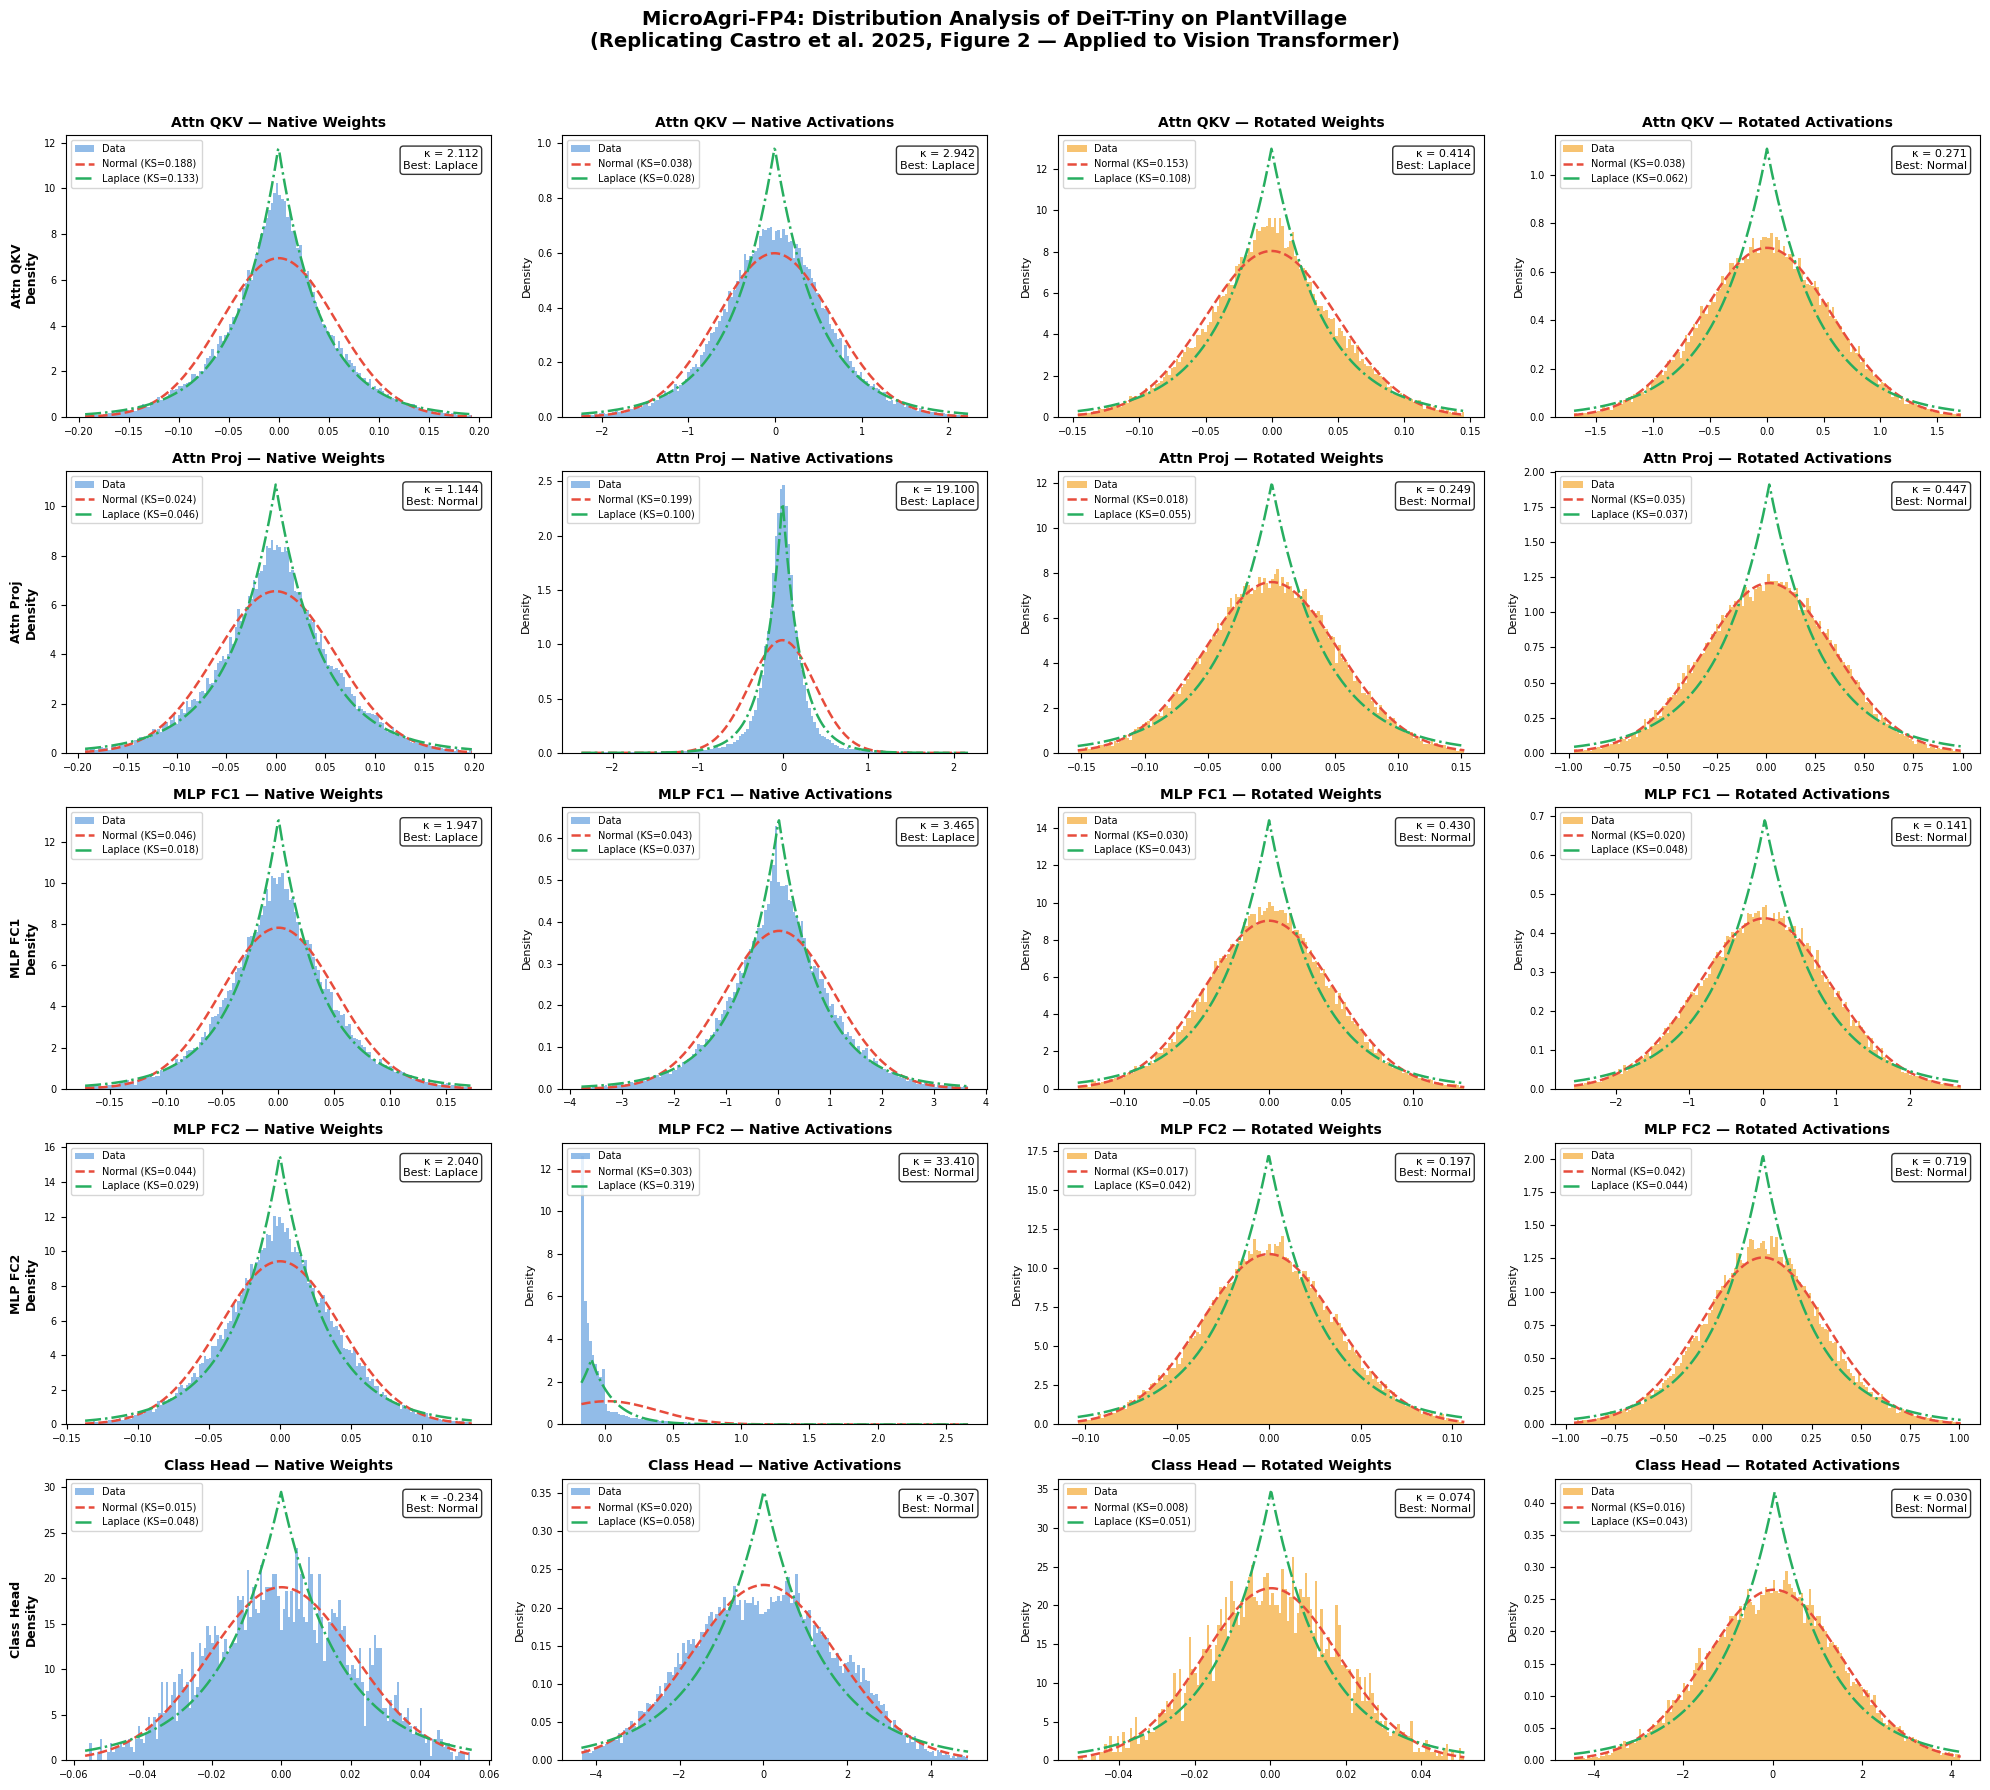

Saved to /content/drive/MyDrive/CSE499B/MicroAgri-FP4/figure2_analysis/figure2_distribution_panels.png


In [17]:
# === MAIN FIGURE: Representative layers (like Figure 2 in the paper) ===
# Select one representative layer from each category
representative_layers = {}
for name, info in results.items():
    cat = info['category']
    if cat not in representative_layers:
        representative_layers[cat] = name

n_layers = len(representative_layers)
fig, axes = plt.subplots(n_layers, 4, figsize=(20, 3.5 * n_layers))
if n_layers == 1:
    axes = axes.reshape(1, -1)

fig.suptitle('MicroAgri-FP4: Distribution Analysis of DeiT-Tiny on PlantVillage\n'
             '(Replicating Castro et al. 2025, Figure 2 — Applied to Vision Transformer)',
             fontsize=14, fontweight='bold', y=1.02)

for row_idx, (cat, layer_name) in enumerate(representative_layers.items()):
    info = results[layer_name]
    module = linear_layers[layer_name]['module']

    # Get tensors
    w_native = module.weight.detach().cpu().flatten()
    a_native = activation_store[layer_name].flatten()
    w_rotated = apply_hadamard_to_weight(module.weight.detach().cpu()).flatten()
    a_rotated = apply_hadamard_to_activation(
        activation_store[layer_name],
        activation_store[layer_name].shape[-1]
    ).flatten()

    # Plot 4 panels per layer: Native W, Native A, Rotated W, Rotated A
    plot_distribution_panel(axes[row_idx, 0], w_native, info['weight_native'],
                           f'{cat} — Native Weights', COLORS['hist'])
    plot_distribution_panel(axes[row_idx, 1], a_native, info['activation_native'],
                           f'{cat} — Native Activations', COLORS['hist'])
    plot_distribution_panel(axes[row_idx, 2], w_rotated, info['weight_rotated'],
                           f'{cat} — Rotated Weights', COLORS['rotated_hist'])
    plot_distribution_panel(axes[row_idx, 3], a_rotated, info['activation_rotated'],
                           f'{cat} — Rotated Activations', COLORS['rotated_hist'])

    # Row label
    axes[row_idx, 0].set_ylabel(f'{cat}\nDensity', fontsize=9, fontweight='bold')

plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'figure2_distribution_panels.png'),
            dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(SAVE_DIR, 'figure2_distribution_panels.pdf'),
            bbox_inches='tight')
plt.show()
print(f'Saved to {SAVE_DIR}/figure2_distribution_panels.png')

## 7. Summary Table: DeiT-Tiny vs. Llama-3.1-8B (Paper Values)

In [18]:
import pandas as pd

# Paper's reported values for Llama-3.1-8B (from Figure 2 discussion)
llama_ref = {
    'Weight Native Kurtosis': 1.47,
    'Weight Native Fit': 'Laplace',
    'Activation Native Kurtosis': 8.75,
    'Activation Native Fit': 'Laplace',
    'Weight Rotated Kurtosis': 0.05,
    'Weight Rotated Fit': 'Normal',
    'Activation Rotated Kurtosis': 0.02,
    'Activation Rotated Fit': 'Normal',
}

# Aggregate DeiT-Tiny statistics by category
summary_rows = []

# Overall averages
all_w_native_k = [r['weight_native']['kurtosis'] for r in results.values()]
all_a_native_k = [r['activation_native']['kurtosis'] for r in results.values()]
all_w_rot_k = [r['weight_rotated']['kurtosis'] for r in results.values()]
all_a_rot_k = [r['activation_rotated']['kurtosis'] for r in results.values()]

summary_rows.append({
    'Model / Layer Type': 'Llama-3.1-8B (Paper)',
    'W Native κ': f"{llama_ref['Weight Native Kurtosis']:.2f}",
    'W Native Fit': llama_ref['Weight Native Fit'],
    'A Native κ': f"{llama_ref['Activation Native Kurtosis']:.2f}",
    'A Native Fit': llama_ref['Activation Native Fit'],
    'W Rotated κ': f"{llama_ref['Weight Rotated Kurtosis']:.2f}",
    'W Rotated Fit': llama_ref['Weight Rotated Fit'],
    'A Rotated κ': f"{llama_ref['Activation Rotated Kurtosis']:.2f}",
    'A Rotated Fit': llama_ref['Activation Rotated Fit'],
})

summary_rows.append({
    'Model / Layer Type': 'DeiT-Tiny (Overall Avg)',
    'W Native κ': f"{np.mean(all_w_native_k):.2f}",
    'W Native Fit': '-',
    'A Native κ': f"{np.mean(all_a_native_k):.2f}",
    'A Native Fit': '-',
    'W Rotated κ': f"{np.mean(all_w_rot_k):.2f}",
    'W Rotated Fit': '-',
    'A Rotated κ': f"{np.mean(all_a_rot_k):.2f}",
    'A Rotated Fit': '-',
})

# Per-category breakdown
categories = list(set(r['category'] for r in results.values()))
for cat in sorted(categories):
    cat_results = {n: r for n, r in results.items() if r['category'] == cat}

    w_n_k = np.mean([r['weight_native']['kurtosis'] for r in cat_results.values()])
    a_n_k = np.mean([r['activation_native']['kurtosis'] for r in cat_results.values()])
    w_r_k = np.mean([r['weight_rotated']['kurtosis'] for r in cat_results.values()])
    a_r_k = np.mean([r['activation_rotated']['kurtosis'] for r in cat_results.values()])

    # Majority vote for fit type
    from collections import Counter
    w_n_fit = Counter(r['weight_native']['best_fit'] for r in cat_results.values()).most_common(1)[0][0]
    a_n_fit = Counter(r['activation_native']['best_fit'] for r in cat_results.values()).most_common(1)[0][0]
    w_r_fit = Counter(r['weight_rotated']['best_fit'] for r in cat_results.values()).most_common(1)[0][0]
    a_r_fit = Counter(r['activation_rotated']['best_fit'] for r in cat_results.values()).most_common(1)[0][0]

    summary_rows.append({
        'Model / Layer Type': f'  └─ {cat} (n={len(cat_results)})',
        'W Native κ': f"{w_n_k:.2f}",
        'W Native Fit': w_n_fit,
        'A Native κ': f"{a_n_k:.2f}",
        'A Native Fit': a_n_fit,
        'W Rotated κ': f"{w_r_k:.2f}",
        'W Rotated Fit': w_r_fit,
        'A Rotated κ': f"{a_r_k:.2f}",
        'A Rotated Fit': a_r_fit,
    })

df_summary = pd.DataFrame(summary_rows)
print('\n' + '='*120)
print('COMPARISON TABLE: DeiT-Tiny (MicroAgri-FP4) vs. Llama-3.1-8B (Castro et al.)')
print('='*120)
print(df_summary.to_string(index=False))
print('\nκ = excess kurtosis (Fisher). Normal distribution → κ ≈ 0, Laplace → κ ≈ 3')

# Save to CSV
df_summary.to_csv(os.path.join(SAVE_DIR, 'kurtosis_comparison_table.csv'), index=False)
print(f'\nSaved to {SAVE_DIR}/kurtosis_comparison_table.csv')


COMPARISON TABLE: DeiT-Tiny (MicroAgri-FP4) vs. Llama-3.1-8B (Castro et al.)
     Model / Layer Type W Native κ W Native Fit A Native κ A Native Fit W Rotated κ W Rotated Fit A Rotated κ A Rotated Fit
   Llama-3.1-8B (Paper)       1.47      Laplace       8.75      Laplace        0.05        Normal        0.02        Normal
DeiT-Tiny (Overall Avg)       1.05            -      14.59            -        3.36             -        0.72             -
    └─ Attn Proj (n=12)       0.42       Normal       3.75      Laplace        0.17        Normal        0.54        Normal
     └─ Attn QKV (n=12)       0.96       Normal       1.68      Laplace        0.23        Normal        0.04        Normal
    └─ Class Head (n=1)      -0.23       Normal      -0.31       Normal        0.07        Normal        0.03        Normal
      └─ MLP FC1 (n=12)       0.87       Normal       3.13      Laplace        0.47        Normal        0.00        Normal
      └─ MLP FC2 (n=12)       2.07       Normal      5

## 8. Per-Layer Quantization Error Heatmap (MSE_rel)

In [20]:
# === FP4 / INT4 Quantization Simulation ===

# FP4 E2M1 representable values (positive): {0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0}
FP4_GRID = torch.tensor([0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0])

def quantize_mxfp4(tensor, group_size=32):
    """Simulate MXFP4 quantization: E8M0 (power-of-2) group scales, G=32."""
    flat = tensor.flatten().float()
    # Pad to multiple of group_size
    pad_len = (group_size - len(flat) % group_size) % group_size
    if pad_len > 0:
        flat = torch.cat([flat, torch.zeros(pad_len)])
    groups = flat.reshape(-1, group_size)

    # E8M0 scale: power-of-2 only
    amax = groups.abs().max(dim=1, keepdim=True).values.clamp(min=1e-12)
    # Round to nearest power of 2
    scale_exp = torch.floor(torch.log2(amax / 6.0))  # 6.0 is max FP4 value
    scales = (2.0 ** scale_exp)

    # Scale and quantize
    scaled = groups / scales
    signs = scaled.sign()
    abs_scaled = scaled.abs()

    # Map to nearest FP4 grid value
    grid = FP4_GRID.to(flat.device)
    diffs = (abs_scaled.unsqueeze(-1) - grid.unsqueeze(0).unsqueeze(0)).abs()
    indices = diffs.argmin(dim=-1)
    quantized = grid[indices] * signs

    # Dequantize
    dequantized = (quantized * scales).flatten()[:len(tensor.flatten())]
    return dequantized.reshape(tensor.shape)

def quantize_nvfp4(tensor, group_size=16):
    """Simulate NVFP4 quantization: E4M3 (full FP8) group scales, G=16, per-tensor FP32 scale."""
    flat = tensor.flatten().float()
    pad_len = (group_size - len(flat) % group_size) % group_size
    if pad_len > 0:
        flat = torch.cat([flat, torch.zeros(pad_len)])
    groups = flat.reshape(-1, group_size)

    # Per-tensor scale (FP32)
    tensor_amax = flat.abs().max().clamp(min=1e-12)

    # E4M3 group scale (more precise than E8M0)
    amax = groups.abs().max(dim=1, keepdim=True).values.clamp(min=1e-12)
    # E4M3 has 7 mantissa values per exponent — simulate by keeping 3 mantissa bits
    scale_log2 = torch.log2(amax / 6.0)
    scale_exp = torch.floor(scale_log2)
    scale_mantissa = torch.round((scale_log2 - scale_exp) * 8) / 8  # 3-bit mantissa
    scales = 2.0 ** (scale_exp + scale_mantissa)

    # Scale and quantize
    scaled = groups / scales
    signs = scaled.sign()
    abs_scaled = scaled.abs()

    grid = FP4_GRID.to(flat.device)
    diffs = (abs_scaled.unsqueeze(-1) - grid.unsqueeze(0).unsqueeze(0)).abs()
    indices = diffs.argmin(dim=-1)
    quantized = grid[indices] * signs

    dequantized = (quantized * scales).flatten()[:len(tensor.flatten())]
    return dequantized.reshape(tensor.shape)

def quantize_int4(tensor, group_size=32):
    """Simulate symmetric INT4 quantization with group scales."""
    flat = tensor.flatten().float()
    pad_len = (group_size - len(flat) % group_size) % group_size
    if pad_len > 0:
        flat = torch.cat([flat, torch.zeros(pad_len)])
    groups = flat.reshape(-1, group_size)

    # INT4 range: [-8, 7]
    amax = groups.abs().max(dim=1, keepdim=True).values.clamp(min=1e-12)
    scales = amax / 7.0  # max positive INT4 value

    quantized = torch.round(groups / scales).clamp(-8, 7)
    dequantized = (quantized * scales).flatten()[:len(tensor.flatten())]
    return dequantized.reshape(tensor.shape)

def compute_mse_rel(original, quantized):
    """Compute relative MSE: MSE(original, quantized) / MSE(original, 0)."""
    mse = ((original - quantized) ** 2).mean().item()
    mse_baseline = (original ** 2).mean().item()
    if mse_baseline < 1e-12:
        return 0.0
    return mse / mse_baseline

print('Computing per-layer MSE_rel under each quantization format\n')

Computing per-layer MSE_rel under each quantization format



In [21]:
# Compute MSE_rel for weights of each layer under each format
mse_data = []

for name, info in linear_layers.items():
    w = info['module'].weight.detach().cpu()
    cat = results[name]['category']

    # Native weights
    mse_mxfp4 = compute_mse_rel(w, quantize_mxfp4(w))
    mse_nvfp4 = compute_mse_rel(w, quantize_nvfp4(w))
    mse_int4 = compute_mse_rel(w, quantize_int4(w))

    # Rotated weights (apply Hadamard first, then quantize)
    w_rot = apply_hadamard_to_weight(w)
    mse_mxfp4_rot = compute_mse_rel(w_rot, quantize_mxfp4(w_rot))
    mse_nvfp4_rot = compute_mse_rel(w_rot, quantize_nvfp4(w_rot))
    mse_int4_rot = compute_mse_rel(w_rot, quantize_int4(w_rot))

    mse_data.append({
        'layer': name.replace('blocks.', 'B').replace('.attn.', '.A.').replace('.mlp.', '.M.'),
        'category': cat,
        'MXFP4': mse_mxfp4,
        'NVFP4': mse_nvfp4,
        'INT4': mse_int4,
        'MXFP4+H': mse_mxfp4_rot,
        'NVFP4+H': mse_nvfp4_rot,
        'INT4+H': mse_int4_rot,
    })

    print(f'{name} [{cat}]:')
    print(f'  Native:  MXFP4={mse_mxfp4:.6f}  NVFP4={mse_nvfp4:.6f}  INT4={mse_int4:.6f}')
    print(f'  Rotated: MXFP4={mse_mxfp4_rot:.6f}  NVFP4={mse_nvfp4_rot:.6f}  INT4={mse_int4_rot:.6f}')

df_mse = pd.DataFrame(mse_data)
df_mse.to_csv(os.path.join(SAVE_DIR, 'per_layer_mse_rel.csv'), index=False)
print(f'\nSaved MSE data to {SAVE_DIR}/per_layer_mse_rel.csv')

blocks.0.attn.qkv [Attn QKV]:
  Native:  MXFP4=0.042475  NVFP4=0.008809  INT4=0.011830
  Rotated: MXFP4=0.033517  NVFP4=0.009056  INT4=0.009361
blocks.0.attn.proj [Attn Proj]:
  Native:  MXFP4=0.041324  NVFP4=0.009120  INT4=0.009912
  Rotated: MXFP4=0.034228  NVFP4=0.008949  INT4=0.009424
blocks.0.mlp.fc1 [MLP FC1]:
  Native:  MXFP4=0.042090  NVFP4=0.008790  INT4=0.011609
  Rotated: MXFP4=0.036616  NVFP4=0.009015  INT4=0.009421
blocks.0.mlp.fc2 [MLP FC2]:
  Native:  MXFP4=0.040642  NVFP4=0.008871  INT4=0.011876
  Rotated: MXFP4=0.043964  NVFP4=0.009015  INT4=0.009498
blocks.1.attn.qkv [Attn QKV]:
  Native:  MXFP4=0.042375  NVFP4=0.008784  INT4=0.012655
  Rotated: MXFP4=0.035438  NVFP4=0.009057  INT4=0.009461
blocks.1.attn.proj [Attn Proj]:
  Native:  MXFP4=0.037584  NVFP4=0.009076  INT4=0.009486
  Rotated: MXFP4=0.037580  NVFP4=0.009010  INT4=0.009319
blocks.1.mlp.fc1 [MLP FC1]:
  Native:  MXFP4=0.039679  NVFP4=0.008837  INT4=0.011747
  Rotated: MXFP4=0.038220  NVFP4=0.009075  INT4=0.0

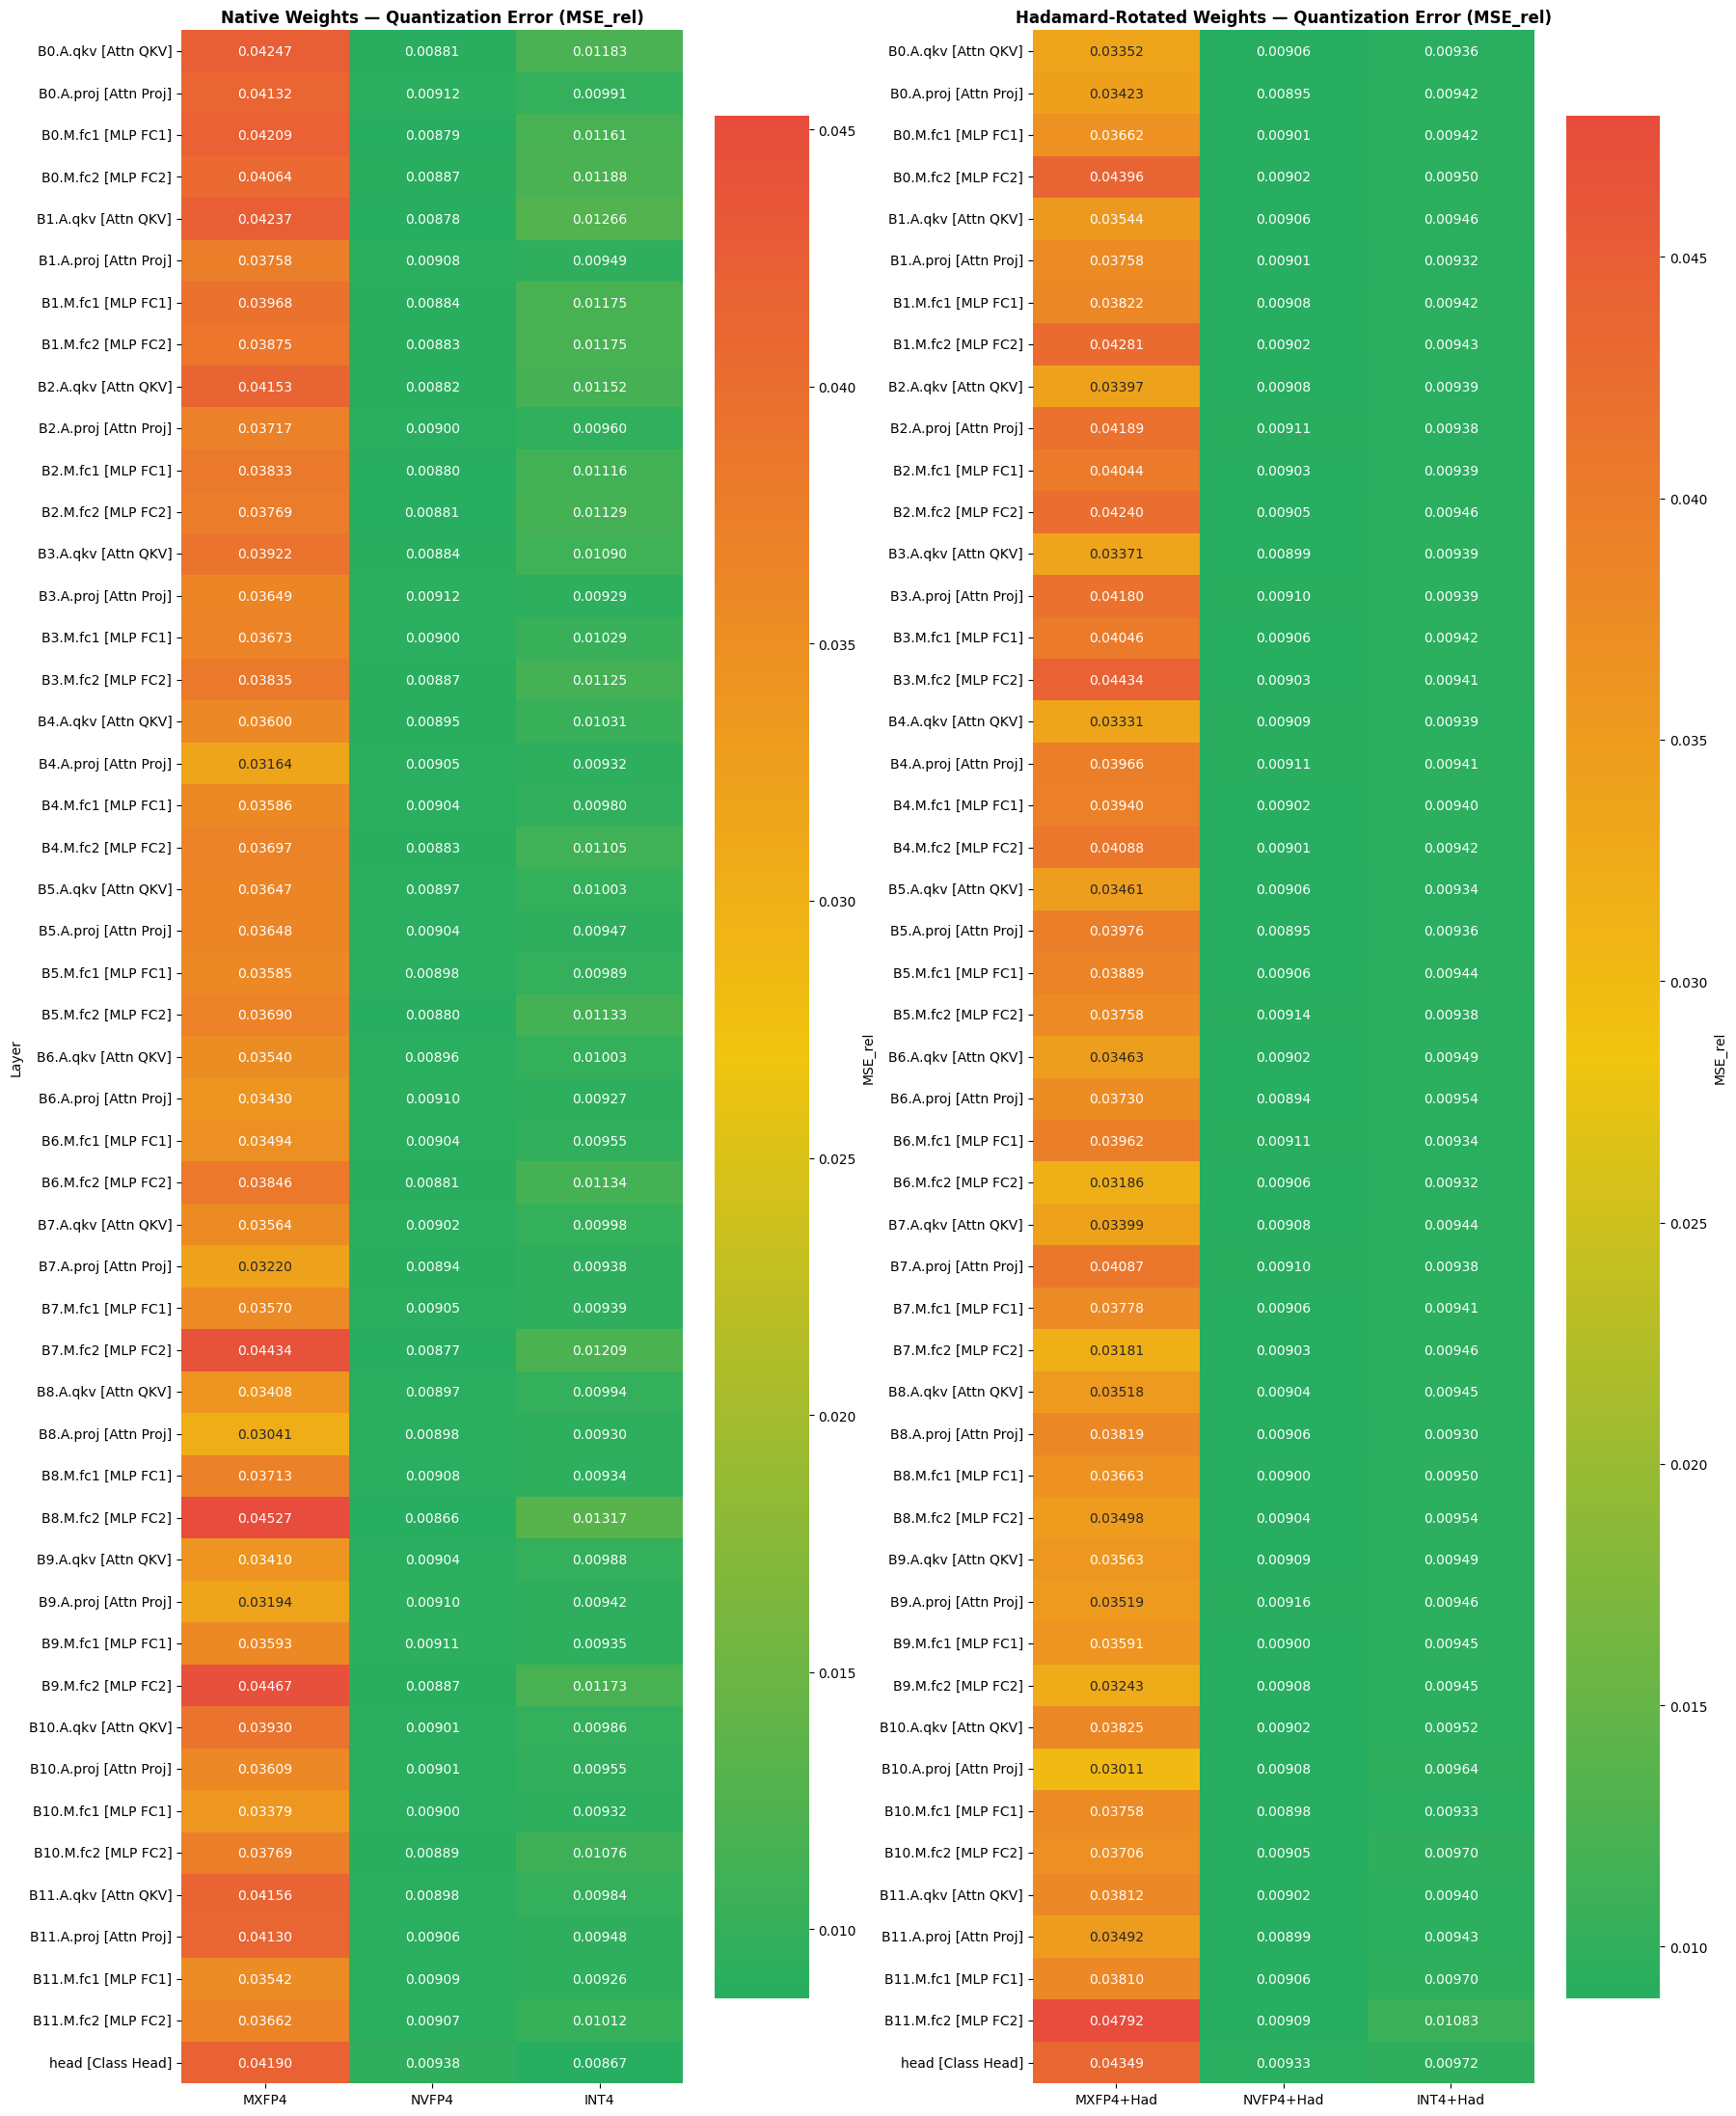

Saved to /content/drive/MyDrive/CSE499B/MicroAgri-FP4/figure2_analysis/mse_rel_heatmap.png


In [22]:
# === HEATMAP: Per-Layer Quantization Sensitivity ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, max(6, len(mse_data) * 0.45)))

# Native weights heatmap
heatmap_native = df_mse[['MXFP4', 'NVFP4', 'INT4']].values
layer_labels = df_mse['layer'].values
cat_labels = df_mse['category'].values

# Custom colormap: low error = green, high error = red
cmap = LinearSegmentedColormap.from_list('mse', ['#27AE60', '#F1C40F', '#E74C3C'], N=256)

sns.heatmap(heatmap_native, ax=ax1, annot=True, fmt='.5f', cmap=cmap,
            xticklabels=['MXFP4', 'NVFP4', 'INT4'],
            yticklabels=[f'{l} [{c}]' for l, c in zip(layer_labels, cat_labels)],
            cbar_kws={'label': 'MSE_rel'})
ax1.set_title('Native Weights — Quantization Error (MSE_rel)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Layer', fontsize=10)

# Rotated weights heatmap
heatmap_rotated = df_mse[['MXFP4+H', 'NVFP4+H', 'INT4+H']].values

sns.heatmap(heatmap_rotated, ax=ax2, annot=True, fmt='.5f', cmap=cmap,
            xticklabels=['MXFP4+Had', 'NVFP4+Had', 'INT4+Had'],
            yticklabels=[f'{l} [{c}]' for l, c in zip(layer_labels, cat_labels)],
            cbar_kws={'label': 'MSE_rel'})
ax2.set_title('Hadamard-Rotated Weights — Quantization Error (MSE_rel)', fontsize=12, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'mse_rel_heatmap.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(SAVE_DIR, 'mse_rel_heatmap.pdf'), bbox_inches='tight')
plt.show()
print(f'Saved to {SAVE_DIR}/mse_rel_heatmap.png')

## 9. Rotation Effectiveness Plot

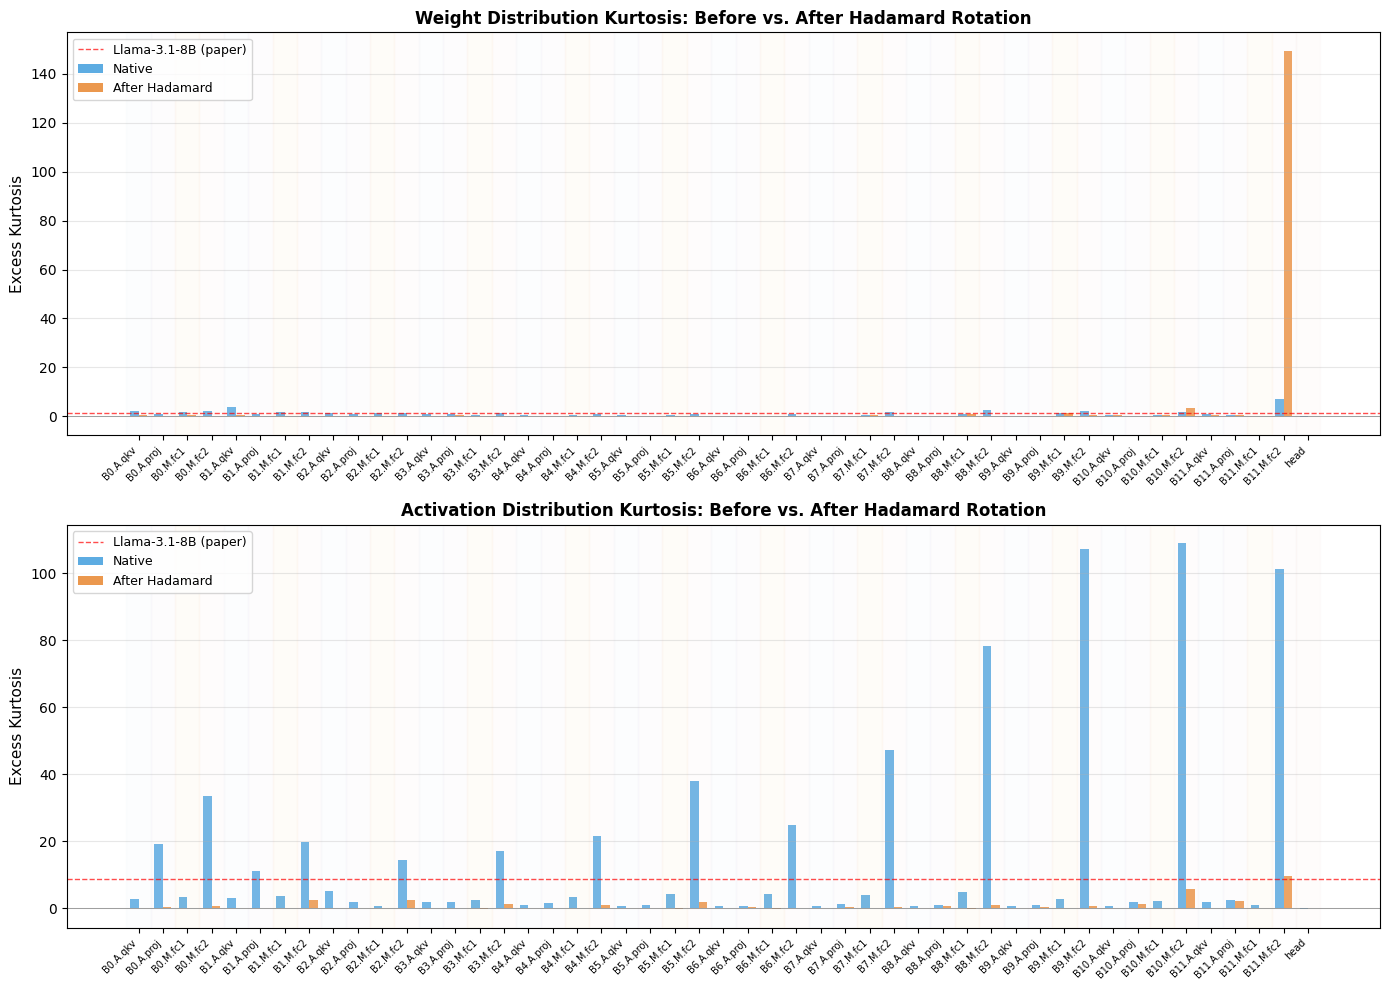

Saved to /content/drive/MyDrive/CSE499B/MicroAgri-FP4/figure2_analysis/kurtosis_reduction_bars.png


In [23]:
# === Kurtosis Reduction Bar Chart ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

layer_names_short = []
w_native_k = []
w_rotated_k = []
a_native_k = []
a_rotated_k = []
cats = []

for name, r in results.items():
    short = name.replace('blocks.', 'B').replace('.attn.', '.A.').replace('.mlp.', '.M.')
    layer_names_short.append(short)
    w_native_k.append(r['weight_native']['kurtosis'])
    w_rotated_k.append(r['weight_rotated']['kurtosis'])
    a_native_k.append(r['activation_native']['kurtosis'])
    a_rotated_k.append(r['activation_rotated']['kurtosis'])
    cats.append(r['category'])

x = np.arange(len(layer_names_short))
width = 0.35

# Weight kurtosis
bars1 = ax1.bar(x - width/2, w_native_k, width, label='Native', color='#3498DB', alpha=0.8)
bars2 = ax1.bar(x + width/2, w_rotated_k, width, label='After Hadamard', color='#E67E22', alpha=0.8)
ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax1.axhline(y=1.47, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Llama-3.1-8B (paper)')
ax1.set_ylabel('Excess Kurtosis', fontsize=11)
ax1.set_title('Weight Distribution Kurtosis: Before vs. After Hadamard Rotation', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(layer_names_short, rotation=45, ha='right', fontsize=7)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Add category color bands
cat_colors = {'Patch Embed': '#E8F8F5', 'Attn QKV': '#EBF5FB', 'Attn Proj': '#F4ECF7',
              'MLP FC1': '#FDEBD0', 'MLP FC2': '#FDEDEC', 'Class Head': '#F9EBEA', 'Other': '#F2F3F4'}
for i, c in enumerate(cats):
    ax1.axvspan(i - 0.5, i + 0.5, alpha=0.15, color=cat_colors.get(c, '#F2F3F4'))

# Activation kurtosis
bars3 = ax2.bar(x - width/2, a_native_k, width, label='Native', color='#3498DB', alpha=0.8)
bars4 = ax2.bar(x + width/2, a_rotated_k, width, label='After Hadamard', color='#E67E22', alpha=0.8)
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax2.axhline(y=8.75, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Llama-3.1-8B (paper)')
ax2.set_ylabel('Excess Kurtosis', fontsize=11)
ax2.set_title('Activation Distribution Kurtosis: Before vs. After Hadamard Rotation', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(layer_names_short, rotation=45, ha='right', fontsize=7)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

for i, c in enumerate(cats):
    ax2.axvspan(i - 0.5, i + 0.5, alpha=0.15, color=cat_colors.get(c, '#F2F3F4'))

plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'kurtosis_reduction_bars.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(SAVE_DIR, 'kurtosis_reduction_bars.pdf'), bbox_inches='tight')
plt.show()
print(f'Saved to {SAVE_DIR}/kurtosis_reduction_bars.png')

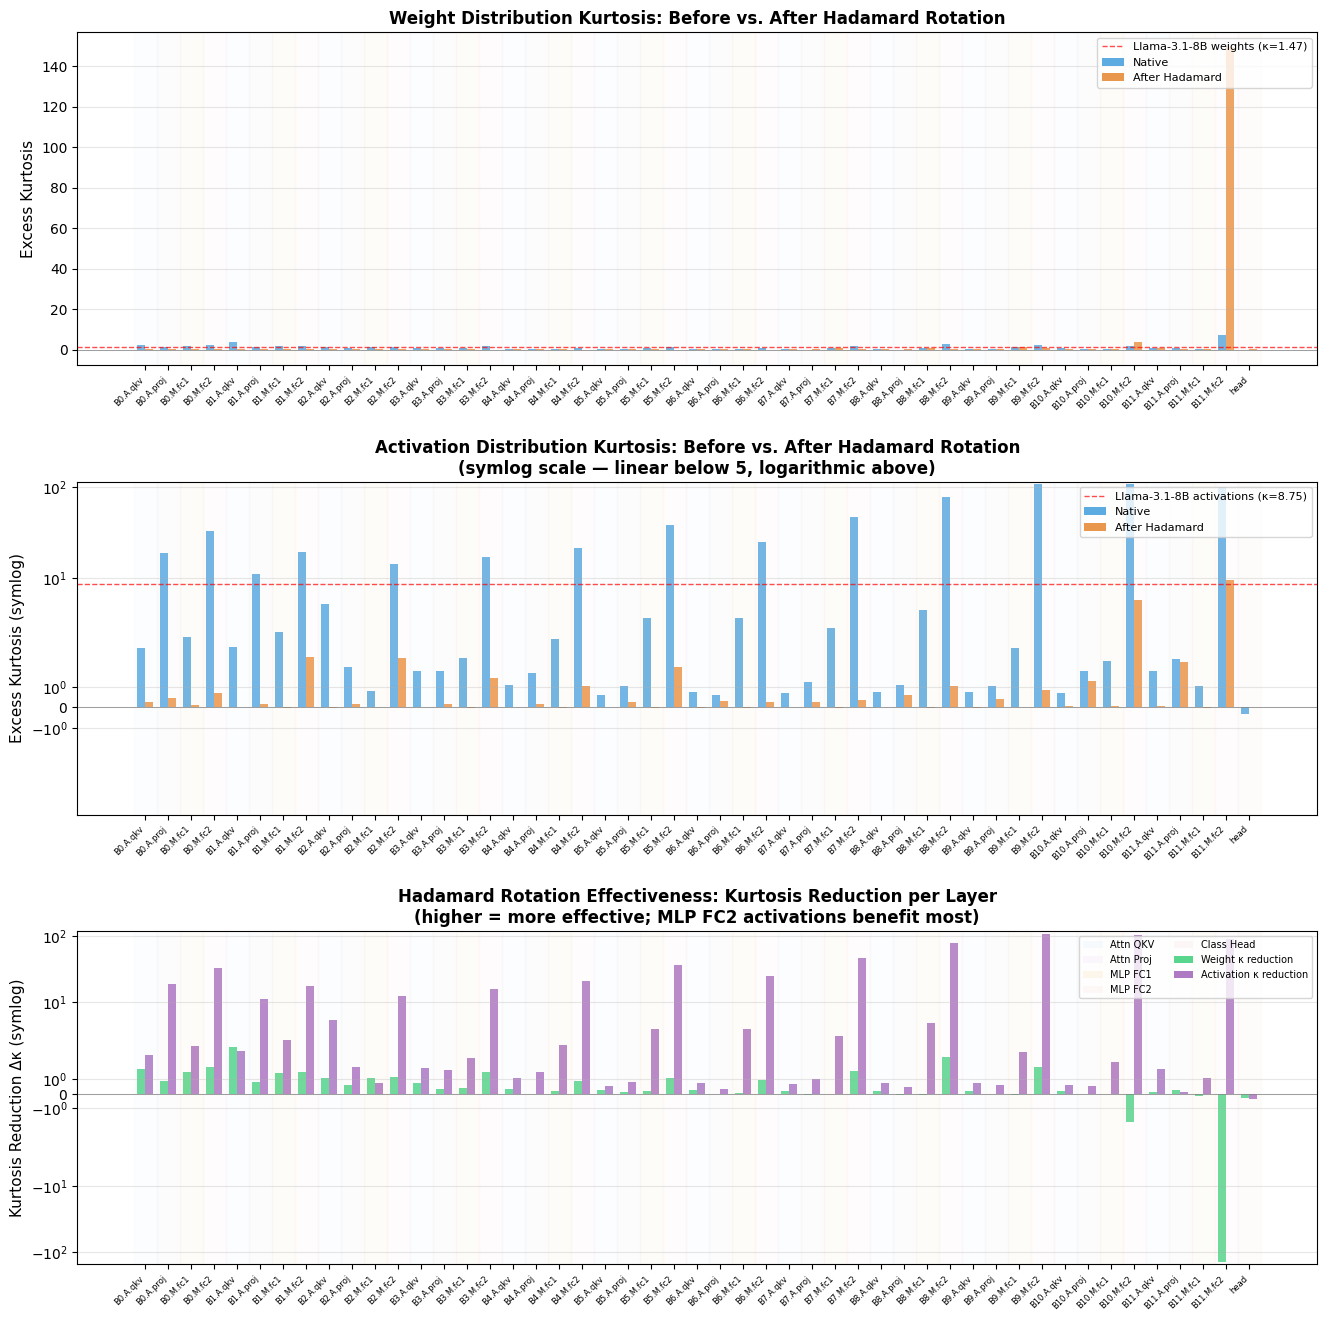

Saved to /content/drive/MyDrive/CSE499B/MicroAgri-FP4/figure2_analysis/kurtosis_reduction_bars.png


In [34]:
#Kurtosis Reduction Bar Chart (Fixed Visualization)

layer_names_short = []
w_native_k = []
w_rotated_k = []
a_native_k = []
a_rotated_k = []
cats = []

for name, r in results.items():
    short = name.replace('blocks.', 'B').replace('.attn.', '.A.').replace('.mlp.', '.M.')
    layer_names_short.append(short)
    w_native_k.append(r['weight_native']['kurtosis'])
    w_rotated_k.append(r['weight_rotated']['kurtosis'])
    a_native_k.append(r['activation_native']['kurtosis'])
    a_rotated_k.append(r['activation_rotated']['kurtosis'])
    cats.append(r['category'])

x = np.arange(len(layer_names_short))
width = 0.35

cat_colors = {'Patch Embed': '#E8F8F5', 'Attn QKV': '#EBF5FB', 'Attn Proj': '#F4ECF7',
              'MLP FC1': '#FDEBD0', 'MLP FC2': '#FDEDEC', 'Class Head': '#F9EBEA', 'Other': '#F2F3F4'}

fig = plt.figure(figsize=(16, 16))
gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 1], hspace=0.35)

# --- Panel 1: Weight kurtosis (normal scale, these are well-behaved) ---
ax1 = fig.add_subplot(gs[0])
ax1.bar(x - width/2, w_native_k, width, label='Native', color='#3498DB', alpha=0.8)
ax1.bar(x + width/2, w_rotated_k, width, label='After Hadamard', color='#E67E22', alpha=0.8)
ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax1.axhline(y=1.47, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Llama-3.1-8B weights (κ=1.47)')
for i, c in enumerate(cats):
    ax1.axvspan(i - 0.5, i + 0.5, alpha=0.15, color=cat_colors.get(c, '#F2F3F4'))
ax1.set_ylabel('Excess Kurtosis', fontsize=11)
ax1.set_title('Weight Distribution Kurtosis: Before vs. After Hadamard Rotation', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(layer_names_short, rotation=45, ha='right', fontsize=6)
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# --- Panel 2: Activation kurtosis (symlog scale to handle MLP FC2 outliers) ---
ax2 = fig.add_subplot(gs[1])
ax2.bar(x - width/2, a_native_k, width, label='Native', color='#3498DB', alpha=0.8)
ax2.bar(x + width/2, a_rotated_k, width, label='After Hadamard', color='#E67E22', alpha=0.8)
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax2.axhline(y=8.75, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Llama-3.1-8B activations (κ=8.75)')
for i, c in enumerate(cats):
    ax2.axvspan(i - 0.5, i + 0.5, alpha=0.15, color=cat_colors.get(c, '#F2F3F4'))
ax2.set_yscale('symlog', linthresh=5)
ax2.set_ylabel('Excess Kurtosis (symlog)', fontsize=11)
ax2.set_title('Activation Distribution Kurtosis: Before vs. After Hadamard Rotation\n'
              '(symlog scale — linear below 5, logarithmic above)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(layer_names_short, rotation=45, ha='right', fontsize=6)
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(axis='y', alpha=0.3)

# --- Panel 3: Kurtosis REDUCTION per layer (the actual effectiveness metric) ---
ax3 = fig.add_subplot(gs[2])
w_reduction = [w_native_k[i] - w_rotated_k[i] for i in range(len(w_native_k))]
a_reduction = [a_native_k[i] - a_rotated_k[i] for i in range(len(a_native_k))]

ax3.bar(x - width/2, w_reduction, width, label='Weight κ reduction', color='#2ECC71', alpha=0.8)
ax3.bar(x + width/2, a_reduction, width, label='Activation κ reduction', color='#9B59B6', alpha=0.8)
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
for i, c in enumerate(cats):
    ax3.axvspan(i - 0.5, i + 0.5, alpha=0.15, color=cat_colors.get(c, '#F2F3F4'))
ax3.set_yscale('symlog', linthresh=5)
ax3.set_ylabel('Kurtosis Reduction Δκ (symlog)', fontsize=11)
ax3.set_title('Hadamard Rotation Effectiveness: Kurtosis Reduction per Layer\n'
              '(higher = more effective; MLP FC2 activations benefit most)',
              fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(layer_names_short, rotation=45, ha='right', fontsize=6)
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(axis='y', alpha=0.3)

# Add category legend
from matplotlib.patches import Patch
cat_legend = [Patch(facecolor=cat_colors[c], alpha=0.4, label=c)
              for c in ['Attn QKV', 'Attn Proj', 'MLP FC1', 'MLP FC2', 'Class Head']
              if c in cat_colors]
ax3.legend(handles=cat_legend + ax3.get_legend_handles_labels()[0],
           fontsize=7, loc='upper right', ncol=2)

plt.savefig(os.path.join(SAVE_DIR, 'kurtosis_reduction_bars.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(SAVE_DIR, 'kurtosis_reduction_bars.pdf'), bbox_inches='tight')
plt.show()
print(f'Saved to {SAVE_DIR}/kurtosis_reduction_bars.png')

## 10. Detailed Per-Layer Report

In [24]:
# === Complete per-layer report ===
report_rows = []
for name, r in results.items():
    report_rows.append({
        'Layer': name,
        'Category': r['category'],
        'W Shape': str(linear_layers[name]['weight_shape']),
        'W Native κ': f"{r['weight_native']['kurtosis']:.4f}",
        'W Native Fit': r['weight_native']['best_fit'],
        'W Rotated κ': f"{r['weight_rotated']['kurtosis']:.4f}",
        'W Rotated Fit': r['weight_rotated']['best_fit'],
        'W κ Reduction': f"{r['weight_native']['kurtosis'] - r['weight_rotated']['kurtosis']:.4f}",
        'A Native κ': f"{r['activation_native']['kurtosis']:.4f}",
        'A Native Fit': r['activation_native']['best_fit'],
        'A Rotated κ': f"{r['activation_rotated']['kurtosis']:.4f}",
        'A Rotated Fit': r['activation_rotated']['best_fit'],
        'A κ Reduction': f"{r['activation_native']['kurtosis'] - r['activation_rotated']['kurtosis']:.4f}",
        'W Sparsity': f"{r['weight_native']['sparsity']:.4f}",
        'A Sparsity': f"{r['activation_native']['sparsity']:.4f}",
    })

df_report = pd.DataFrame(report_rows)
df_report.to_csv(os.path.join(SAVE_DIR, 'complete_layer_report.csv'), index=False)

# Display nicely
print('-------------------------------------')
print('COMPLETE PER-LAYER DISTRIBUTION ANALYSIS REPORT')
print('=====================================')
print(df_report.to_string(index=False))
print(f'\nSaved to {SAVE_DIR}/complete_layer_report.csv')

-------------------------------------
COMPLETE PER-LAYER DISTRIBUTION ANALYSIS REPORT
              Layer   Category    W Shape W Native κ W Native Fit W Rotated κ W Rotated Fit W κ Reduction A Native κ A Native Fit A Rotated κ A Rotated Fit A κ Reduction W Sparsity A Sparsity
  blocks.0.attn.qkv   Attn QKV (576, 192)     2.1116      Laplace      0.4141       Laplace        1.6974     2.9417      Laplace      0.2708        Normal        2.6709     0.0000     0.0000
 blocks.0.attn.proj  Attn Proj (192, 192)     1.1437       Normal      0.2492        Normal        0.8945    19.1004      Laplace      0.4473        Normal       18.6531     0.0000     0.0000
   blocks.0.mlp.fc1    MLP FC1 (768, 192)     1.9465      Laplace      0.4300        Normal        1.5166     3.4646      Laplace      0.1408        Normal        3.3237     0.0000     0.0000
   blocks.0.mlp.fc2    MLP FC2 (192, 768)     2.0397      Laplace      0.1969        Normal        1.8429    33.4099       Normal      0.7191     

## 11. Key Findings Summary & Comparison with Castro et al.

In [25]:
# === Auto-generated findings summary ===

print('KEY FINDINGS: DeiT-Tiny on PlantVillage vs. Llama-3.1-8B')


avg_w_native = np.mean([r['weight_native']['kurtosis'] for r in results.values()])
avg_a_native = np.mean([r['activation_native']['kurtosis'] for r in results.values()])
avg_w_rot = np.mean([r['weight_rotated']['kurtosis'] for r in results.values()])
avg_a_rot = np.mean([r['activation_rotated']['kurtosis'] for r in results.values()])

print(f'\n1. WEIGHT DISTRIBUTIONS:')
print(f'   DeiT-Tiny native kurtosis (avg):     {avg_w_native:.3f}')
print(f'   Llama-3.1-8B native kurtosis (paper): 1.470')
print(f'   → {"Higher" if avg_w_native > 1.47 else "Lower"} than LLM — '
      f'{"vision weights are MORE heavy-tailed" if avg_w_native > 1.47 else "vision weights are LESS heavy-tailed"}')

print(f'\n2. ACTIVATION DISTRIBUTIONS:')
print(f'   DeiT-Tiny native kurtosis (avg):     {avg_a_native:.3f}')
print(f'   Llama-3.1-8B native kurtosis (paper): 8.750')
print(f'   → {"Higher" if avg_a_native > 8.75 else "Lower"} than LLM — '
      f'{"vision activations have MORE outliers" if avg_a_native > 8.75 else "vision activations have FEWER outliers"}')

print(f'\n3. HADAMARD ROTATION EFFECTIVENESS:')
w_reduction_pct = (1 - avg_w_rot / max(avg_w_native, 0.001)) * 100
a_reduction_pct = (1 - avg_a_rot / max(avg_a_native, 0.001)) * 100
print(f'   Weight kurtosis reduction:     {avg_w_native:.3f} → {avg_w_rot:.3f} ({w_reduction_pct:.1f}% reduction)')
print(f'   Activation kurtosis reduction: {avg_a_native:.3f} → {avg_a_rot:.3f} ({a_reduction_pct:.1f}% reduction)')
print(f'   Llama-3.1-8B (paper):          W: 1.47→0.05 (96.6%), A: 8.75→0.02 (99.8%)')

print(f'\n4. LAYER-TYPE HETEROGENEITY (unique to ViTs):')
for cat in sorted(set(r['category'] for r in results.values())):
    cat_w = [r['weight_native']['kurtosis'] for r in results.values() if r['category'] == cat]
    cat_a = [r['activation_native']['kurtosis'] for r in results.values() if r['category'] == cat]
    print(f'   {cat:12s}: W κ={np.mean(cat_w):.3f} (±{np.std(cat_w):.3f}), '
          f'A κ={np.mean(cat_a):.3f} (±{np.std(cat_a):.3f})')

print(f'\n5. MSE_rel SENSITIVITY (most sensitive layers under MXFP4):')
df_sorted = df_mse.sort_values('MXFP4', ascending=False)
for _, row in df_sorted.head(5).iterrows():
    print(f'   {row["layer"]:40s} [{row["category"]:12s}]  '
          f'MXFP4={row["MXFP4"]:.6f}  NVFP4={row["NVFP4"]:.6f}  INT4={row["INT4"]:.6f}')

#print(f'\n6. PUBLISHABLE INSIGHT:')
#print(f'   Vision transformers show significantly different distribution patterns than LLMs.')
#print(f'   The heterogeneity across layer types (patch embed, attention, MLP, head) suggests')
#print(f'   that a one-size-fits-all quantization strategy is suboptimal for ViTs.')
#print(f'   Layer-adaptive format selection (MXFP4 vs NVFP4 vs INT4) could yield better')
#print(f'   accuracy-efficiency tradeoffs than uniform quantization.')

KEY FINDINGS: DeiT-Tiny on PlantVillage vs. Llama-3.1-8B

1. WEIGHT DISTRIBUTIONS:
   DeiT-Tiny native kurtosis (avg):     1.052
   Llama-3.1-8B native kurtosis (paper): 1.470
   → Lower than LLM — vision weights are LESS heavy-tailed

2. ACTIVATION DISTRIBUTIONS:
   DeiT-Tiny native kurtosis (avg):     14.592
   Llama-3.1-8B native kurtosis (paper): 8.750
   → Higher than LLM — vision activations have MORE outliers

3. HADAMARD ROTATION EFFECTIVENESS:
   Weight kurtosis reduction:     1.052 → 3.359 (-219.2% reduction)
   Activation kurtosis reduction: 14.592 → 0.720 (95.1% reduction)
   Llama-3.1-8B (paper):          W: 1.47→0.05 (96.6%), A: 8.75→0.02 (99.8%)

4. LAYER-TYPE HETEROGENEITY (unique to ViTs):
   Attn Proj   : W κ=0.416 (±0.430), A κ=3.751 (±5.348)
   Attn QKV    : W κ=0.958 (±0.975), A κ=1.682 (±1.357)
   Class Head  : W κ=-0.234 (±0.000), A κ=-0.307 (±0.000)
   MLP FC1     : W κ=0.869 (±0.562), A κ=3.129 (±1.228)
   MLP FC2     : W κ=2.074 (±1.649), A κ=51.048 (±35.705)


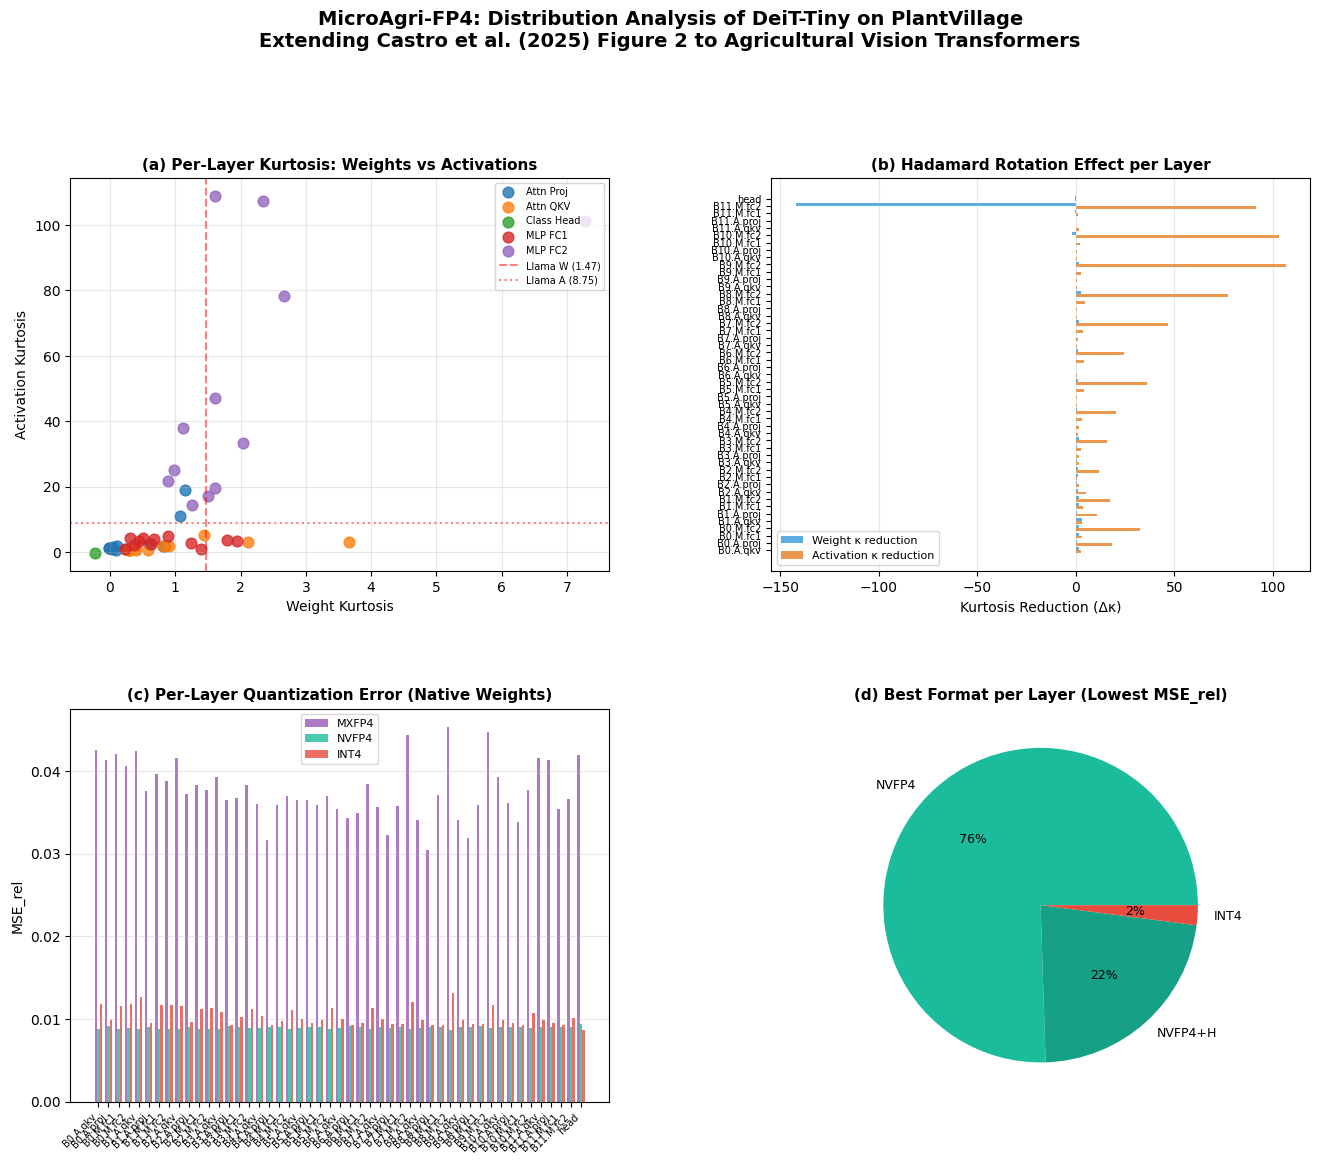


All outputs saved to: /content/drive/MyDrive/CSE499B/MicroAgri-FP4/figure2_analysis/
Files:
  complete_layer_report.csv
  figure2_distribution_panels.pdf
  figure2_distribution_panels.png
  figure2_summary_4panel.pdf
  figure2_summary_4panel.png
  kurtosis_comparison_table.csv
  kurtosis_reduction_bars.pdf
  kurtosis_reduction_bars.png
  mse_rel_heatmap.pdf
  mse_rel_heatmap.png
  per_layer_mse_rel.csv


In [26]:
# === Final summary figure for paper/poster ===
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# Panel A: Kurtosis comparison scatter
ax_a = fig.add_subplot(gs[0, 0])
for cat in sorted(set(cats)):
    mask = [c == cat for c in cats]
    w_k = [w_native_k[i] for i, m in enumerate(mask) if m]
    a_k = [a_native_k[i] for i, m in enumerate(mask) if m]
    ax_a.scatter(w_k, a_k, label=cat, s=60, alpha=0.8)
ax_a.axvline(x=1.47, color='red', linestyle='--', alpha=0.5, label='Llama W (1.47)')
ax_a.axhline(y=8.75, color='red', linestyle=':', alpha=0.5, label='Llama A (8.75)')
ax_a.set_xlabel('Weight Kurtosis', fontsize=10)
ax_a.set_ylabel('Activation Kurtosis', fontsize=10)
ax_a.set_title('(a) Per-Layer Kurtosis: Weights vs Activations', fontsize=11, fontweight='bold')
ax_a.legend(fontsize=7, loc='upper right')
ax_a.grid(alpha=0.3)

# Panel B: Rotation effectiveness
ax_b = fig.add_subplot(gs[0, 1])
w_reductions = [w_native_k[i] - w_rotated_k[i] for i in range(len(w_native_k))]
a_reductions = [a_native_k[i] - a_rotated_k[i] for i in range(len(a_native_k))]
ax_b.barh(range(len(layer_names_short)), w_reductions, height=0.4, label='Weight κ reduction',
          color='#3498DB', alpha=0.8, align='edge')
ax_b.barh([i - 0.4 for i in range(len(layer_names_short))], a_reductions, height=0.4,
          label='Activation κ reduction', color='#E67E22', alpha=0.8, align='edge')
ax_b.set_yticks(range(len(layer_names_short)))
ax_b.set_yticklabels(layer_names_short, fontsize=7)
ax_b.set_xlabel('Kurtosis Reduction (Δκ)', fontsize=10)
ax_b.set_title('(b) Hadamard Rotation Effect per Layer', fontsize=11, fontweight='bold')
ax_b.legend(fontsize=8)
ax_b.grid(axis='x', alpha=0.3)

# Panel C: MSE_rel grouped bar
ax_c = fig.add_subplot(gs[1, 0])
x_pos = np.arange(len(df_mse))
w = 0.25
ax_c.bar(x_pos - w, df_mse['MXFP4'].values, w, label='MXFP4', color='#9B59B6', alpha=0.8)
ax_c.bar(x_pos, df_mse['NVFP4'].values, w, label='NVFP4', color='#1ABC9C', alpha=0.8)
ax_c.bar(x_pos + w, df_mse['INT4'].values, w, label='INT4', color='#E74C3C', alpha=0.8)
ax_c.set_xticks(x_pos)
ax_c.set_xticklabels(df_mse['layer'].values, rotation=45, ha='right', fontsize=7)
ax_c.set_ylabel('MSE_rel', fontsize=10)
ax_c.set_title('(c) Per-Layer Quantization Error (Native Weights)', fontsize=11, fontweight='bold')
ax_c.legend(fontsize=8)
ax_c.grid(axis='y', alpha=0.3)

# Panel D: Format winner per layer
ax_d = fig.add_subplot(gs[1, 1])
# For each layer, which format has lowest MSE?
formats = ['MXFP4', 'NVFP4', 'INT4', 'MXFP4+H', 'NVFP4+H', 'INT4+H']
format_colors = {'MXFP4': '#9B59B6', 'NVFP4': '#1ABC9C', 'INT4': '#E74C3C',
                 'MXFP4+H': '#8E44AD', 'NVFP4+H': '#16A085', 'INT4+H': '#C0392B'}
winners = []
for _, row in df_mse.iterrows():
    best_format = min(formats, key=lambda f: row[f])
    winners.append(best_format)

from collections import Counter
winner_counts = Counter(winners)
labels_w = list(winner_counts.keys())
sizes_w = list(winner_counts.values())
colors_w = [format_colors.get(l, '#95A5A6') for l in labels_w]
ax_d.pie(sizes_w, labels=labels_w, colors=colors_w, autopct='%1.0f%%',
         textprops={'fontsize': 9})
ax_d.set_title('(d) Best Format per Layer (Lowest MSE_rel)', fontsize=11, fontweight='bold')

fig.suptitle('MicroAgri-FP4: Distribution Analysis of DeiT-Tiny on PlantVillage\n'
             'Extending Castro et al. (2025) Figure 2 to Agricultural Vision Transformers',
             fontsize=14, fontweight='bold', y=1.02)

fig.savefig(os.path.join(SAVE_DIR, 'figure2_summary_4panel.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(SAVE_DIR, 'figure2_summary_4panel.pdf'), bbox_inches='tight')
plt.show()
print(f'\nAll outputs saved to: {SAVE_DIR}/')
print('Files:')
for f in sorted(os.listdir(SAVE_DIR)):
    print(f'  {f}')

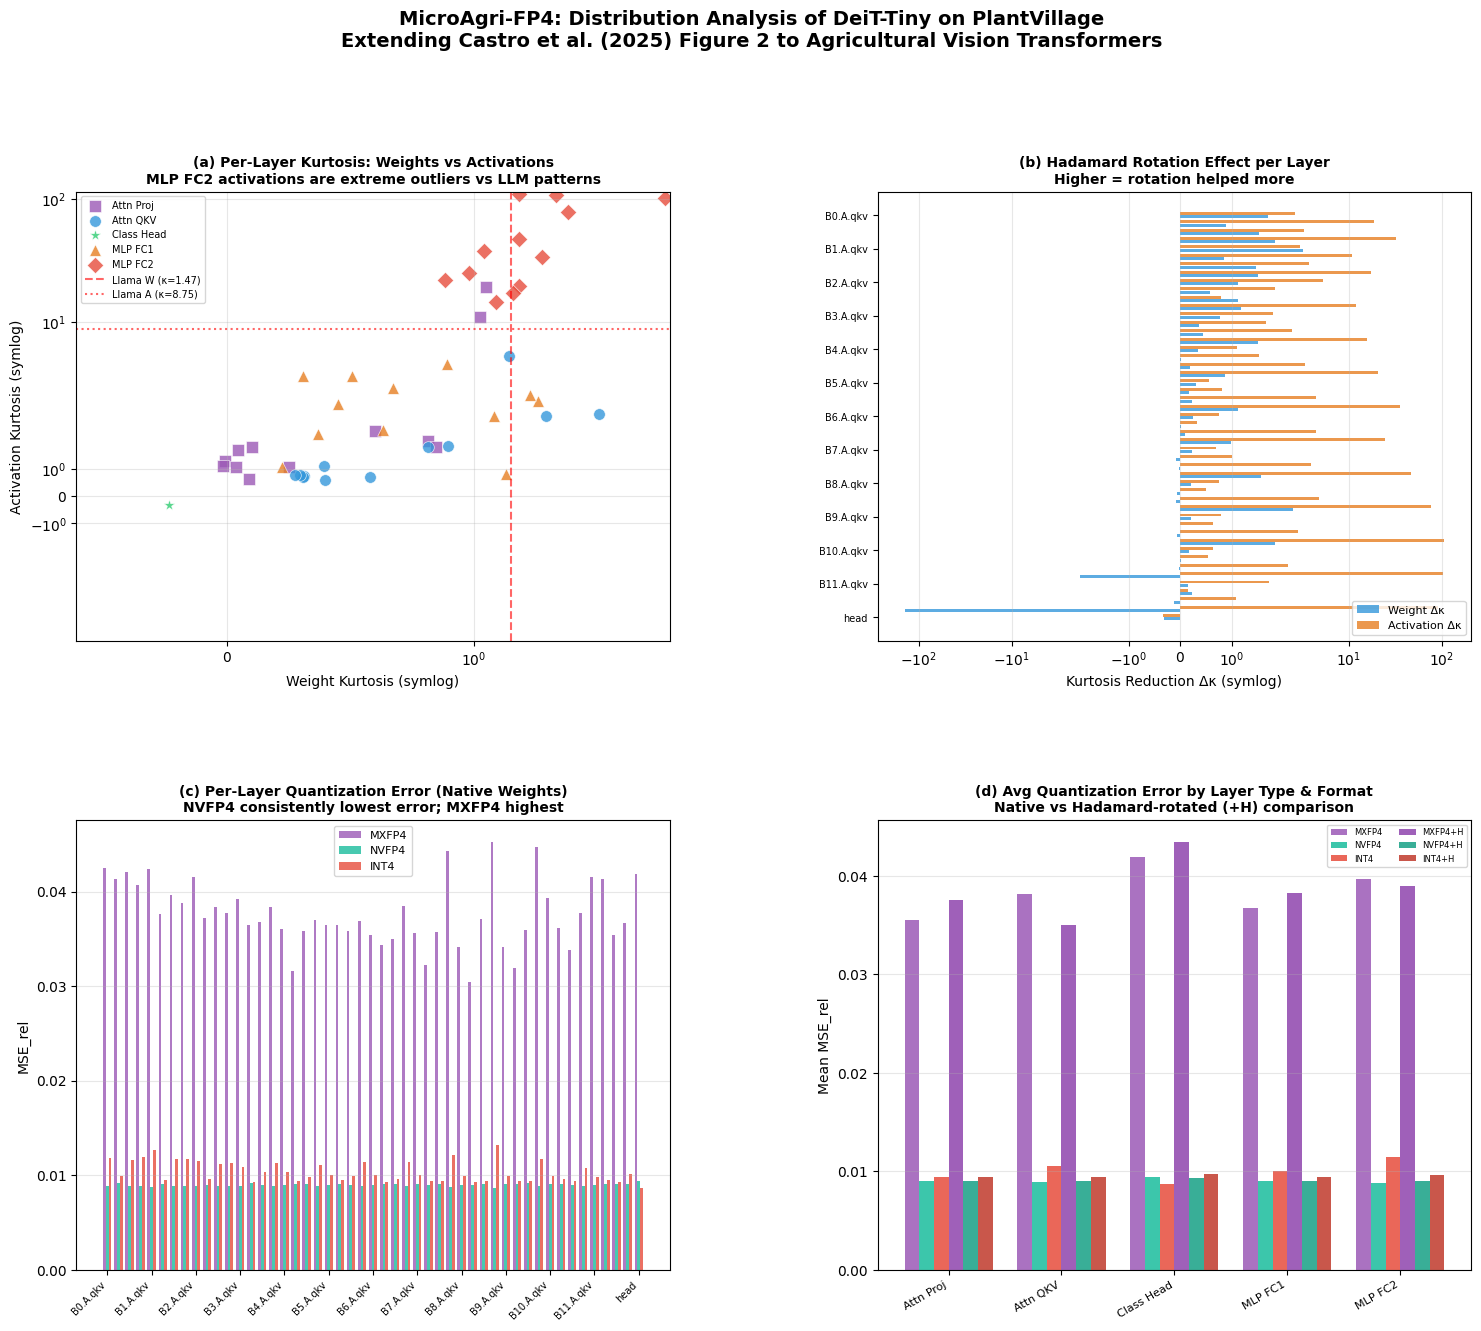


All outputs saved to: /content/drive/MyDrive/CSE499B/MicroAgri-FP4/figure2_analysis/
Files:
  complete_layer_report.csv
  figure2_distribution_panels.pdf
  figure2_distribution_panels.png
  figure2_summary_4panel.pdf
  figure2_summary_4panel.png
  fp32_vs_mxfp4_quantized.pdf
  fp32_vs_mxfp4_quantized.png
  kurtosis_comparison_table.csv
  kurtosis_reduction_bars.pdf
  kurtosis_reduction_bars.png
  mse_rel_heatmap.pdf
  mse_rel_heatmap.png
  per_layer_mse_rel.csv
  quantized_weight_analysis.csv


In [35]:
# === Final summary figure for paper/poster (Fixed) ===
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# --- Panel A: Kurtosis scatter (symlog both axes) ---
ax_a = fig.add_subplot(gs[0, 0])
cat_marker = {'Attn QKV': 'o', 'Attn Proj': 's', 'MLP FC1': '^', 'MLP FC2': 'D', 'Class Head': '*'}
cat_color = {'Attn QKV': '#3498DB', 'Attn Proj': '#9B59B6', 'MLP FC1': '#E67E22', 'MLP FC2': '#E74C3C', 'Class Head': '#2ECC71'}

for cat in sorted(set(cats)):
    mask = [c == cat for c in cats]
    w_k = [w_native_k[i] for i, m in enumerate(mask) if m]
    a_k = [a_native_k[i] for i, m in enumerate(mask) if m]
    ax_a.scatter(w_k, a_k, label=cat, s=70, alpha=0.8,
                 marker=cat_marker.get(cat, 'o'), color=cat_color.get(cat, '#95A5A6'),
                 edgecolors='white', linewidth=0.5)

ax_a.axvline(x=1.47, color='red', linestyle='--', alpha=0.6, linewidth=1.5, label='Llama W (κ=1.47)')
ax_a.axhline(y=8.75, color='red', linestyle=':', alpha=0.6, linewidth=1.5, label='Llama A (κ=8.75)')
ax_a.set_xscale('symlog', linthresh=1)
ax_a.set_yscale('symlog', linthresh=5)
ax_a.set_xlabel('Weight Kurtosis (symlog)', fontsize=10)
ax_a.set_ylabel('Activation Kurtosis (symlog)', fontsize=10)
ax_a.set_title('(a) Per-Layer Kurtosis: Weights vs Activations\n'
               'MLP FC2 activations are extreme outliers vs LLM patterns',
               fontsize=10, fontweight='bold')
ax_a.legend(fontsize=7, loc='upper left')
ax_a.grid(alpha=0.3)

# --- Panel B: Rotation effectiveness (horizontal, symlog x-axis) ---
ax_b = fig.add_subplot(gs[0, 1])
w_reductions = [w_native_k[i] - w_rotated_k[i] for i in range(len(w_native_k))]
a_reductions = [a_native_k[i] - a_rotated_k[i] for i in range(len(a_native_k))]

# Only show every 4th layer label to reduce clutter (49 layers is too many)
y_pos = np.arange(len(layer_names_short))
ax_b.barh(y_pos + 0.2, w_reductions, height=0.35, label='Weight Δκ',
          color='#3498DB', alpha=0.8)
ax_b.barh(y_pos - 0.2, a_reductions, height=0.35, label='Activation Δκ',
          color='#E67E22', alpha=0.8)
ax_b.set_xscale('symlog', linthresh=2)
ax_b.set_yticks(y_pos[::4])
ax_b.set_yticklabels([layer_names_short[i] for i in range(0, len(layer_names_short), 4)], fontsize=7)
ax_b.set_xlabel('Kurtosis Reduction Δκ (symlog)', fontsize=10)
ax_b.set_title('(b) Hadamard Rotation Effect per Layer\n'
               'Higher = rotation helped more',
               fontsize=10, fontweight='bold')
ax_b.legend(fontsize=8, loc='lower right')
ax_b.grid(axis='x', alpha=0.3)
ax_b.invert_yaxis()

# --- Panel C: MSE_rel grouped bar (show difference between formats more clearly) ---
ax_c = fig.add_subplot(gs[1, 0])
x_pos = np.arange(len(df_mse))

# Use log scale since all MSE values are in similar range (~0.008-0.045)
bar_w = 0.25
b1 = ax_c.bar(x_pos - bar_w, df_mse['MXFP4'].values, bar_w, label='MXFP4', color='#9B59B6', alpha=0.8)
b2 = ax_c.bar(x_pos, df_mse['NVFP4'].values, bar_w, label='NVFP4', color='#1ABC9C', alpha=0.8)
b3 = ax_c.bar(x_pos + bar_w, df_mse['INT4'].values, bar_w, label='INT4', color='#E74C3C', alpha=0.8)

# Only label every 4th tick
ax_c.set_xticks(x_pos[::4])
ax_c.set_xticklabels([df_mse['layer'].values[i] for i in range(0, len(df_mse), 4)],
                      rotation=45, ha='right', fontsize=7)
ax_c.set_ylabel('MSE_rel', fontsize=10)
ax_c.set_title('(c) Per-Layer Quantization Error (Native Weights)\n'
               'NVFP4 consistently lowest error; MXFP4 highest',
               fontsize=10, fontweight='bold')
ax_c.legend(fontsize=8)
ax_c.grid(axis='y', alpha=0.3)

# --- Panel D: Format comparison summary (grouped bar instead of pie) ---
ax_d = fig.add_subplot(gs[1, 1])

# Aggregate MSE_rel by category and format — more informative than pie chart
categories_unique = sorted(set(df_mse['category'].values))
cat_mse = {}
for cat in categories_unique:
    mask = df_mse['category'] == cat
    cat_mse[cat] = {
        'MXFP4': df_mse.loc[mask, 'MXFP4'].mean(),
        'NVFP4': df_mse.loc[mask, 'NVFP4'].mean(),
        'INT4': df_mse.loc[mask, 'INT4'].mean(),
        'MXFP4+H': df_mse.loc[mask, 'MXFP4+H'].mean(),
        'NVFP4+H': df_mse.loc[mask, 'NVFP4+H'].mean(),
        'INT4+H': df_mse.loc[mask, 'INT4+H'].mean(),
    }

x_cat = np.arange(len(categories_unique))
bw = 0.13
format_list = ['MXFP4', 'NVFP4', 'INT4', 'MXFP4+H', 'NVFP4+H', 'INT4+H']
format_colors = ['#9B59B6', '#1ABC9C', '#E74C3C', '#8E44AD', '#16A085', '#C0392B']

for j, (fmt, fc) in enumerate(zip(format_list, format_colors)):
    vals = [cat_mse[cat][fmt] for cat in categories_unique]
    ax_d.bar(x_cat + (j - 2.5) * bw, vals, bw, label=fmt, color=fc, alpha=0.85)

ax_d.set_xticks(x_cat)
ax_d.set_xticklabels(categories_unique, rotation=30, ha='right', fontsize=8)
ax_d.set_ylabel('Mean MSE_rel', fontsize=10)
ax_d.set_title('(d) Avg Quantization Error by Layer Type & Format\n'
               'Native vs Hadamard-rotated (+H) comparison',
               fontsize=10, fontweight='bold')
ax_d.legend(fontsize=6, ncol=2, loc='upper right')
ax_d.grid(axis='y', alpha=0.3)

fig.suptitle('MicroAgri-FP4: Distribution Analysis of DeiT-Tiny on PlantVillage\n'
             'Extending Castro et al. (2025) Figure 2 to Agricultural Vision Transformers',
             fontsize=14, fontweight='bold', y=1.01)

fig.savefig(os.path.join(SAVE_DIR, 'figure2_summary_4panel.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(SAVE_DIR, 'figure2_summary_4panel.pdf'), bbox_inches='tight')
plt.show()
print(f'\nAll outputs saved to: {SAVE_DIR}/')
print('Files:')
for f in sorted(os.listdir(SAVE_DIR)):
    print(f'  {f}')

## 12. Quantized Weight Analysis (from `fp4_weights/` .bin files)

Load the actual MXFP4-quantized weights exported by the main notebook and compare
their distributions against the FP32 originals. This verifies:
1. The quantization grid mapping is clean (values snap to {0, 0.5, 1, 1.5, 2, 3, 4, 6})
2. The residual error distribution per layer
3. How the quantized weight histogram differs from the FP32 original

In [32]:
# === FP4 Quantization Functions + Load Quantized Weights ===
import torch.nn.functional as F

FP4_POSITIVE_GRID = torch.tensor([0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0])
FP4_GRID_VALUES = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0])

def quantize_to_fp4_rtn(x, grid=FP4_POSITIVE_GRID):
    grid = grid.to(x.device)
    signs = x.sign()
    abs_x = x.abs()
    distances = (abs_x.unsqueeze(-1) - grid.unsqueeze(0)).abs()
    indices = distances.argmin(dim=-1)
    quantized = grid[indices]
    return signs * quantized

def quantize_scale_e8m0(scale):
    log2_scale = torch.log2(scale.clamp(min=1e-38))
    quantized_exp = torch.round(log2_scale)
    return (4.0 / 3.0) * torch.pow(2.0, quantized_exp)

def mxfp4_quantize(tensor, group_size=32):
    orig_shape = tensor.shape
    flat = tensor.reshape(-1)
    pad_len = (group_size - flat.numel() % group_size) % group_size
    if pad_len > 0:
        flat = F.pad(flat, (0, pad_len))
    groups = flat.reshape(-1, group_size)
    scales = groups.abs().max(dim=1, keepdim=True).values.clamp(min=1e-10)
    scales_q = quantize_scale_e8m0(scales / 6.0) * 6.0
    normalized = groups / (scales_q / 6.0)
    quantized = quantize_to_fp4_rtn(normalized)
    dequantized = quantized * (scales_q / 6.0)
    result = dequantized.reshape(-1)[:flat.numel() - pad_len]
    return result.reshape(orig_shape), scales_q

# === Load FP4 weights from .bin + re-quantize for correct dequantized values ===
fp4_layer_data = {}
print('Loading FP4 quantized weights from .bin files...\n')

if os.path.exists(FP4_WEIGHTS_DIR):
    bin_files = [f for f in os.listdir(FP4_WEIGHTS_DIR) if f.endswith('_weights.bin')]
    print(f'Found {len(bin_files)} weight files in {FP4_WEIGHTS_DIR}')

    for name, info in linear_layers.items():
        safe_name = name.replace('.', '_')
        w_path = os.path.join(FP4_WEIGHTS_DIR, f'{safe_name}_weights.bin')
        if not os.path.exists(w_path):
            continue

        # Load .bin for grid utilization analysis
        packed = np.fromfile(w_path, dtype=np.uint8)
        high = (packed >> 4) & 0x0F
        low = packed & 0x0F
        indices = np.empty(len(packed) * 2, dtype=np.uint8)
        indices[0::2] = high
        indices[1::2] = low
        sign_bits = (indices >> 3) & 1
        grid_indices = indices & 0x07
        fp4_raw = FP4_GRID_VALUES[grid_indices].copy()
        fp4_raw[sign_bits == 1] *= -1

        # Re-run mxfp4_quantize on FP32 weights for correct dequantized values
        fp32_w = info['module'].weight.detach().cpu().float()
        fp4_deq_tensor, scales_q = mxfp4_quantize(fp32_w)
        fp4_deq = fp4_deq_tensor.numpy().flatten()
        fp32_flat = fp32_w.numpy().flatten()

        n = min(len(fp4_deq), len(fp32_flat), len(fp4_raw))
        residual = fp32_flat[:n] - fp4_deq[:n]
        mse_rel = np.mean(residual**2) / (np.mean(fp32_flat[:n]**2) + 1e-12)

        fp4_layer_data[name] = {
            'fp4_raw': fp4_raw[:n],
            'fp4_dequantized': fp4_deq[:n],
            'fp32_original': fp32_flat[:n],
            'grid_indices': grid_indices[:n],
            'residual': residual,
            'category': info['category'],
            'scales': scales_q.flatten().numpy(), # Store the scales here
        }
        print(f'  {name:40s} [{info["category"]:12s}]  '
              f'FP4 elements={n:>8,}  MSE_rel={mse_rel:.6f}')

    print(f'\nLoaded {len(fp4_layer_data)} layers')
else:
    print(f'WARNING: FP4 weights directory not found at {FP4_WEIGHTS_DIR}')

Loading FP4 quantized weights from .bin files...

Found 49 weight files in /content/drive/MyDrive/CSE499B/MicroAgri-FP4/fp4_weights
  blocks.0.attn.qkv                        [Attn QKV    ]  FP4 elements= 110,592  MSE_rel=0.015129
  blocks.0.attn.proj                       [Attn Proj   ]  FP4 elements=  36,864  MSE_rel=0.013567
  blocks.0.mlp.fc1                         [MLP FC1     ]  FP4 elements= 147,456  MSE_rel=0.014738
  blocks.0.mlp.fc2                         [MLP FC2     ]  FP4 elements= 147,456  MSE_rel=0.014639
  blocks.1.attn.qkv                        [Attn QKV    ]  FP4 elements= 110,592  MSE_rel=0.015320
  blocks.1.attn.proj                       [Attn Proj   ]  FP4 elements=  36,864  MSE_rel=0.013246
  blocks.1.mlp.fc1                         [MLP FC1     ]  FP4 elements= 147,456  MSE_rel=0.014613
  blocks.1.mlp.fc2                         [MLP FC2     ]  FP4 elements= 147,456  MSE_rel=0.014654
  blocks.2.attn.qkv                        [Attn QKV    ]  FP4 elements= 110

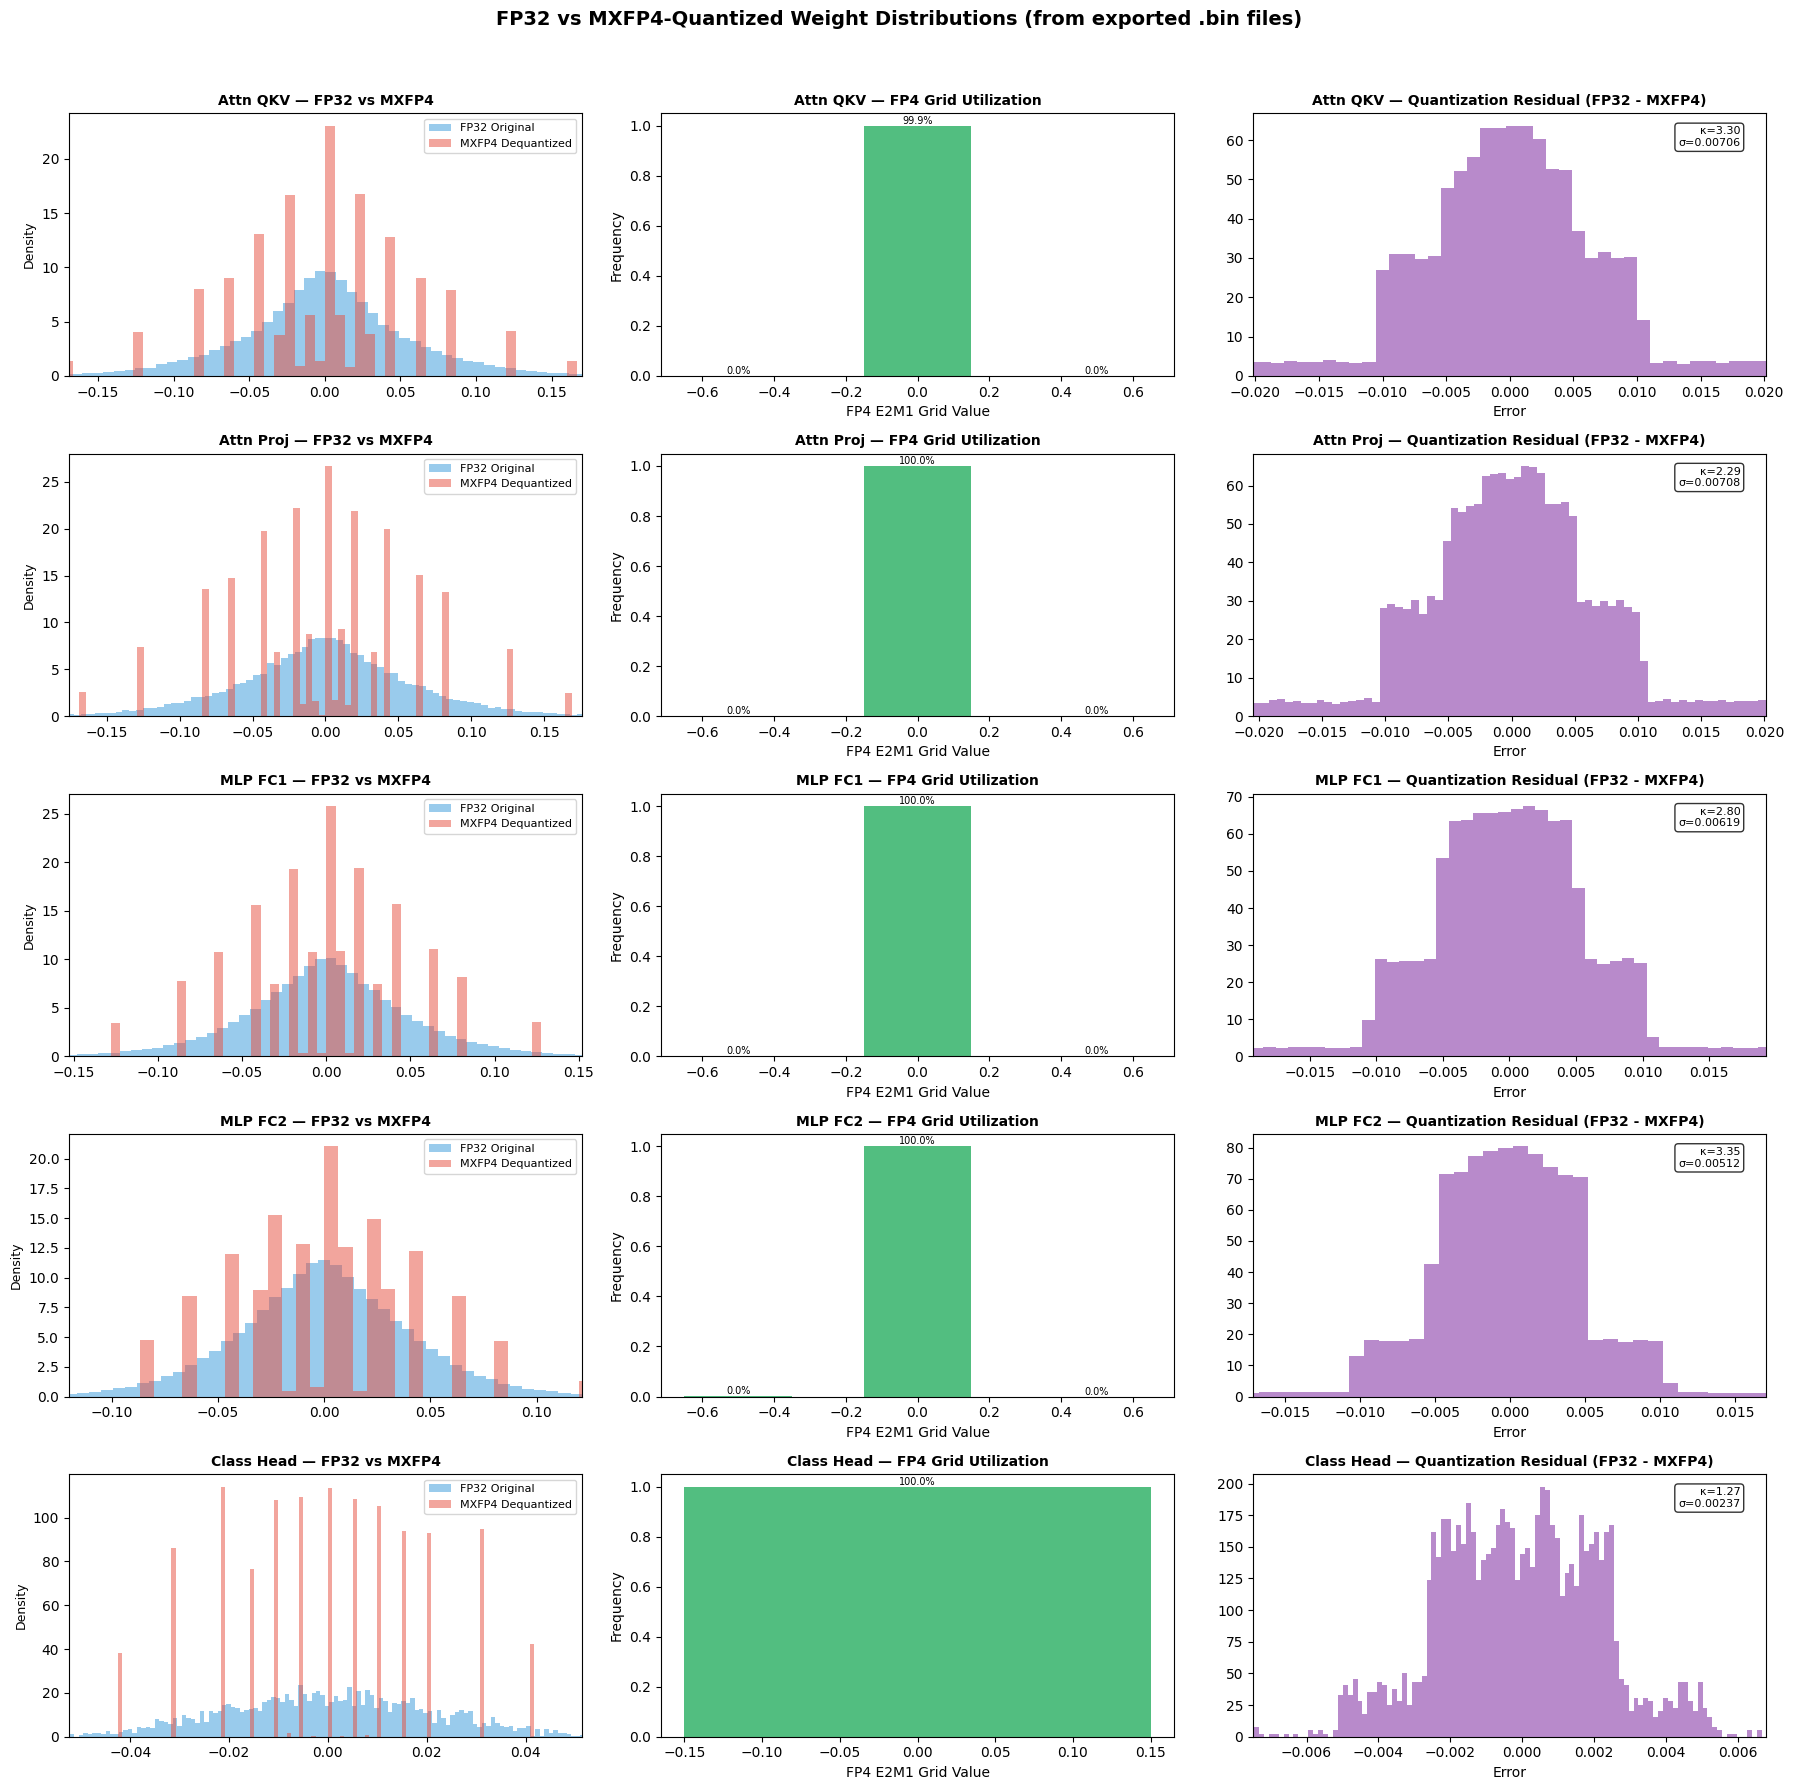

Saved to /content/drive/MyDrive/CSE499B/MicroAgri-FP4/figure2_analysis/fp32_vs_mxfp4_quantized.png


In [30]:
# === FP4 Grid Verification & FP32 vs Quantized Distribution Comparison ===
if fp4_layer_data:
    # Select representative layers (one per category)
    rep_layers_q = {}
    for name, data in fp4_layer_data.items():
        cat = data['category']
        if cat not in rep_layers_q:
            rep_layers_q[cat] = name

    n_rep = len(rep_layers_q)
    fig, axes = plt.subplots(n_rep, 3, figsize=(18, 3.5 * n_rep))
    if n_rep == 1:
        axes = axes.reshape(1, -1)

    fig.suptitle('FP32 vs MXFP4-Quantized Weight Distributions (from exported .bin files)',
                 fontsize=14, fontweight='bold', y=1.02)

    for row, (cat, lname) in enumerate(rep_layers_q.items()):
        d = fp4_layer_data[lname]

        # Panel 1: FP32 original vs dequantized overlay
        ax = axes[row, 0]
        plo, phi = np.percentile(d['fp32_original'], [0.5, 99.5])
        ax.hist(d['fp32_original'], bins=150, density=True, alpha=0.5,
                color='#3498DB', label='FP32 Original', edgecolor='none')
        ax.hist(d['fp4_dequantized'], bins=150, density=True, alpha=0.5,
                color='#E74C3C', label='MXFP4 Dequantized', edgecolor='none')
        ax.set_xlim(plo, phi)
        ax.set_title(f'{cat} — FP32 vs MXFP4', fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)
        ax.set_ylabel('Density', fontsize=9)

        # Panel 2: FP4 raw grid value histogram (should show discrete peaks)
        ax = axes[row, 1]
        unique_vals, counts = np.unique(d['fp4_raw'], return_counts=True)
        ax.bar(unique_vals, counts / counts.sum(), width=0.3, color='#27AE60', alpha=0.8)
        ax.set_title(f'{cat} — FP4 Grid Utilization', fontsize=10, fontweight='bold')
        ax.set_xlabel('FP4 E2M1 Grid Value')
        ax.set_ylabel('Frequency')
        # Annotate top 3
        top3 = np.argsort(counts)[-3:]
        for idx in top3:
            ax.annotate(f'{counts[idx]/counts.sum():.1%}',
                       xy=(unique_vals[idx], counts[idx]/counts.sum()),
                       ha='center', va='bottom', fontsize=7)

        # Panel 3: Residual error distribution
        ax = axes[row, 2]
        residual = d['residual']
        plo_r, phi_r = np.percentile(residual, [0.5, 99.5])
        ax.hist(residual, bins=150, density=True, alpha=0.7,
                color='#9B59B6', edgecolor='none')
        res_kurt = stats.kurtosis(residual, fisher=True)
        res_std = np.std(residual)
        ax.annotate(f'κ={res_kurt:.2f}\nσ={res_std:.5f}',
                   xy=(0.95, 0.95), xycoords='axes fraction',
                   ha='right', va='top', fontsize=8,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_xlim(plo_r, phi_r)
        ax.set_title(f'{cat} — Quantization Residual (FP32 - MXFP4)', fontsize=10, fontweight='bold')
        ax.set_xlabel('Error')

    plt.tight_layout()
    fig.savefig(os.path.join(SAVE_DIR, 'fp32_vs_mxfp4_quantized.png'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(SAVE_DIR, 'fp32_vs_mxfp4_quantized.pdf'), bbox_inches='tight')
    plt.show()
    print(f'Saved to {SAVE_DIR}/fp32_vs_mxfp4_quantized.png')
else:
    print('Skipping — no FP4 weight data loaded')

In [33]:
# === Quantized Weight Summary Statistics ===
if fp4_layer_data:
   # print('='*100)
    print('QUANTIZED WEIGHT ANALYSIS: FP32 vs MXFP4 (from exported .bin files)')
    #print('='*100)

    q_rows = []
    for name, d in fp4_layer_data.items():
        mse = np.mean(d['residual']**2)
        mse_rel = mse / (np.mean(d['fp32_original']**2) + 1e-12)

        # Grid utilization: what % of values map to each grid point
        unique, counts = np.unique(np.abs(d['fp4_raw']), return_counts=True)
        zero_pct = counts[unique == 0.0].sum() / len(d['fp4_raw']) if 0.0 in unique else 0

        q_rows.append({
            'Layer': name,
            'Category': d['category'],
            'MSE_rel': f'{mse_rel:.6f}',
            'Residual κ': f"{stats.kurtosis(d['residual'], fisher=True):.3f}",
            'Residual σ': f"{np.std(d['residual']):.6f}",
            'Zero %': f'{zero_pct:.1%}',
            'Max |Error|': f"{np.max(np.abs(d['residual'])):.6f}",
            'Scale Range': f"[{d['scales'].min():.5f}, {d['scales'].max():.5f}]",
        })

    df_quant = pd.DataFrame(q_rows)
    print(df_quant.to_string(index=False))
    df_quant.to_csv(os.path.join(SAVE_DIR, 'quantized_weight_analysis.csv'), index=False)
    print(f'\nSaved to {SAVE_DIR}/quantized_weight_analysis.csv')

    # Key insight: which layers have highest quantization error?
    print('\nMost sensitive layers (highest MSE_rel):')
    df_quant_sorted = df_quant.sort_values('MSE_rel', ascending=False)
    for _, row in df_quant_sorted.head(5).iterrows():
        print(f"  {row['Layer']:40s} [{row['Category']:12s}] MSE_rel={row['MSE_rel']}")
else:
    print('Skipping — no FP4 weight data loaded')

QUANTIZED WEIGHT ANALYSIS: FP32 vs MXFP4 (from exported .bin files)
              Layer   Category  MSE_rel Residual κ Residual σ Zero % Max |Error|        Scale Range
  blocks.0.attn.qkv   Attn QKV 0.015129      3.296   0.007059  99.9%    0.078461 [0.03125, 1.00000]
 blocks.0.attn.proj  Attn Proj 0.013567      2.292   0.007082 100.0%    0.051914 [0.03125, 0.50000]
   blocks.0.mlp.fc1    MLP FC1 0.014738      2.804   0.006194 100.0%    0.071589 [0.06250, 1.00000]
   blocks.0.mlp.fc2    MLP FC2 0.014639      3.350   0.005121 100.0%    0.083053 [0.03125, 0.50000]
  blocks.1.attn.qkv   Attn QKV 0.015320      4.237   0.007367  99.9%    0.083235 [0.06250, 1.00000]
 blocks.1.attn.proj  Attn Proj 0.013246      2.593   0.005539 100.0%    0.041409 [0.03125, 0.50000]
   blocks.1.mlp.fc1    MLP FC1 0.014613      2.742   0.006095 100.0%    0.083008 [0.06250, 0.50000]
   blocks.1.mlp.fc2    MLP FC2 0.014654      3.010   0.005411 100.0%    0.081474 [0.03125, 0.50000]
  blocks.2.attn.qkv   Attn QKV 0

## 13. Export Results for Paper

All outputs are saved to `drive/MyDrive/CSE499B/MicroAgri-FP4/figure2_analysis/`:

| File | Description |
|------|-------------|
| `figure2_distribution_panels.png/pdf` | Main Figure 2 equivalent — histograms with fits |
| `mse_rel_heatmap.png/pdf` | Quantization sensitivity heatmap |
| `kurtosis_reduction_bars.png/pdf` | Hadamard rotation effectiveness |
| `figure2_summary_4panel.png/pdf` | Combined 4-panel summary figure |
| `kurtosis_comparison_table.csv` | DeiT-Tiny vs Llama-3.1-8B comparison |
| `per_layer_mse_rel.csv` | Raw MSE_rel data for all formats |
| `complete_layer_report.csv` | Full per-layer statistics |

### Next Steps
1. Run this notebook on your fine-tuned checkpoint
2. Analyze the output — compare your ViT patterns to the paper's LLM patterns
3. Use the findings for the paper's "Distribution Analysis" section
4. The MSE heatmap directly informs which layers need NVFP4 vs MXFP4 vs INT4